<div style="background: linear-gradient(135deg, #2b1055 0%, #3a1c71 40%, #1f4068 100%);
padding: 35px 28px; border-radius: 14px; margin-bottom: 20px;
border-left: 6px solid #00f5d4; font-family: Georgia, serif;">

<h1 style="color: #ffffff; font-size: 2.2em; margin: 0 0 6px 0; letter-spacing: 0.8px;">
March Machine Learning Mania 2026
</h1>

<h2 style="color: #00f5d4; font-size: 1.15em; margin: 0 0 14px 0; font-weight: 400;">
Probabilistic Modeling of NCAA Tournament Matchups
</h2>

<p style="color: #e0e0f0; font-size: 0.95em; margin: 0; line-height: 1.6;">
A data-driven framework for forecasting the 2026 NCAA Division I Men’s and Women’s Basketball Tournaments.<br>
This notebook builds dynamic Elo ratings, derives Four Factors efficiency metrics, engineers contextual signals 
(conference strength, schedule difficulty, momentum), and integrates LightGBM, XGBoost, and CatBoost 
into a calibrated gradient boosting ensemble.<br>
Validated on 2022–2025 tournaments and optimized using Brier score.
</p>

</div>

#  Sheikh Abdul Rehman

Aspiring AI Engineer | AI Researcher & Applied Scientist | Data Analytics Enthusiast

<a id="1-overview-and-objective"></a>  
## 1. Overview and Objective  

The objective is to predict the probability that one team defeats another in every possible NCAA tournament matchup. Submissions are evaluated using the **Brier score** (mean squared error between predicted probabilities and actual outcomes); lower scores indicate better performance.

### Competition Structure

- **Stage 1 (2022–2025):** Development phase using historical data. Since results are already known, data leakage can produce perfect scores, making this leaderboard non-representative.  
- **Stage 2 (2026):** Final evaluation phase. All predictions must be submitted before the tournament begins. This stage determines official rankings and prizes.

### Methodology

Our approach combines three feature groups:

- **Elo ratings**
- **Four Factors efficiency metrics**
- **Contextual indicators** (conference strength, schedule difficulty, momentum, coaching experience)

These features are fed into an ensemble of gradient boosting models to generate robust probability predictions.

<a id="2-setup"></a>
## 2. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
from pathlib import Path
import warnings, time

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

PALETTE = ["#0f3460", "#e94560", "#16213e", "#533483", "#1a1a2e"]
sns.set_theme(style="whitegrid", palette=PALETTE, font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "serif",
})


CLIP_LO, CLIP_HI = 0.02, 0.98
SEED_DEFAULT = 8.5
RS = 42

t_start = time.time()
print("Setup complete.")

Setup complete.


<a id="3-data-loading-and-inventory"></a>
## 3. Data Loading and Inventory

We load all relevant files and create a quick inventory of temporal coverage and row counts.

In [ ]:
m_rs    = pd.read_csv(DATA / "MRegularSeasonCompactResults.csv")
m_det   = pd.read_csv(DATA / "MRegularSeasonDetailedResults.csv")
m_trn   = pd.read_csv(DATA / "MNCAATourneyCompactResults.csv")
m_sec   = pd.read_csv(DATA / "MSecondaryTourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA / "MNCAATourneySeeds.csv")
m_conf  = pd.read_csv(DATA / "MTeamConferences.csv")
m_coach = pd.read_csv(DATA / "MTeamCoaches.csv")
m_teams = pd.read_csv(DATA / "MTeams.csv")

w_rs    = pd.read_csv(DATA / "WRegularSeasonCompactResults.csv")
w_det   = pd.read_csv(DATA / "WRegularSeasonDetailedResults.csv")
w_trn   = pd.read_csv(DATA / "WNCAATourneyCompactResults.csv")
w_sec   = pd.read_csv(DATA / "WSecondaryTourneyCompactResults.csv")
w_seeds = pd.read_csv(DATA / "WNCAATourneySeeds.csv")
w_conf  = pd.read_csv(DATA / "WTeamConferences.csv")
w_teams = pd.read_csv(DATA / "WTeams.csv")

sub1 = pd.read_csv(DATA / "SampleSubmissionStage1.csv")
sub2 = pd.read_csv(DATA / "SampleSubmissionStage2.csv")

m_seeds["SeedNum"] = m_seeds["Seed"].str[1:3].astype(int)
w_seeds["SeedNum"] = w_seeds["Seed"].str[1:3].astype(int)

inventory = pd.DataFrame([
    ["Men Regular Season (compact)",  m_rs["Season"].min(),  m_rs["Season"].max(),  len(m_rs)],
    ["Men Regular Season (detailed)", m_det["Season"].min(), m_det["Season"].max(), len(m_det)],
    ["Men NCAA Tournament",           m_trn["Season"].min(), m_trn["Season"].max(), len(m_trn)],
    ["Men Tournament Seeds",          m_seeds["Season"].min(), m_seeds["Season"].max(), len(m_seeds)],
    ["Women Regular Season (compact)",w_rs["Season"].min(),  w_rs["Season"].max(),  len(w_rs)],
    ["Women Regular Season (detailed)",w_det["Season"].min(),w_det["Season"].max(), len(w_det)],
    ["Women NCAA Tournament",         w_trn["Season"].min(), w_trn["Season"].max(), len(w_trn)],
    ["Women Tournament Seeds",        w_seeds["Season"].min(),w_seeds["Season"].max(),len(w_seeds)],
], columns=["Dataset", "First Season", "Last Season", "Rows"])
inventory["Rows"] = inventory["Rows"].apply(lambda x: f"{x:,}")
display(inventory.style.set_properties(**{"text-align": "left"}).hide(axis="index"))

print(f"\nStage 1 submission: {len(sub1):,} matchups (seasons {sub1['ID'].str[:4].unique()})")
print(f"Stage 2 submission: {len(sub2):,} matchups (season 2026)")

Dataset,First Season,Last Season,Rows
Men Regular Season (compact),1985,2026,"196,823"
Men Regular Season (detailed),2003,2026,"122,775"
Men NCAA Tournament,1985,2025,"2,585"
Men Tournament Seeds,1985,2025,"2,626"
Women Regular Season (compact),1998,2026,"140,825"
Women Regular Season (detailed),2010,2026,"85,505"
Women NCAA Tournament,1998,2025,"1,717"
Women Tournament Seeds,1998,2025,"1,744"



Stage 1 submission: 519,144 matchups (seasons ['2022' '2023' '2024' '2025'])
Stage 2 submission: 132,133 matchups (season 2026)


<a id="4-exploratory-data-analysis"></a>
## 4. Exploratory Data Analysis

Before engineering features, we examine the data to understand the key drivers of tournament outcomes. 
The insights from this section directly inform our feature choices.

### 4.1 Seed Predictive Power

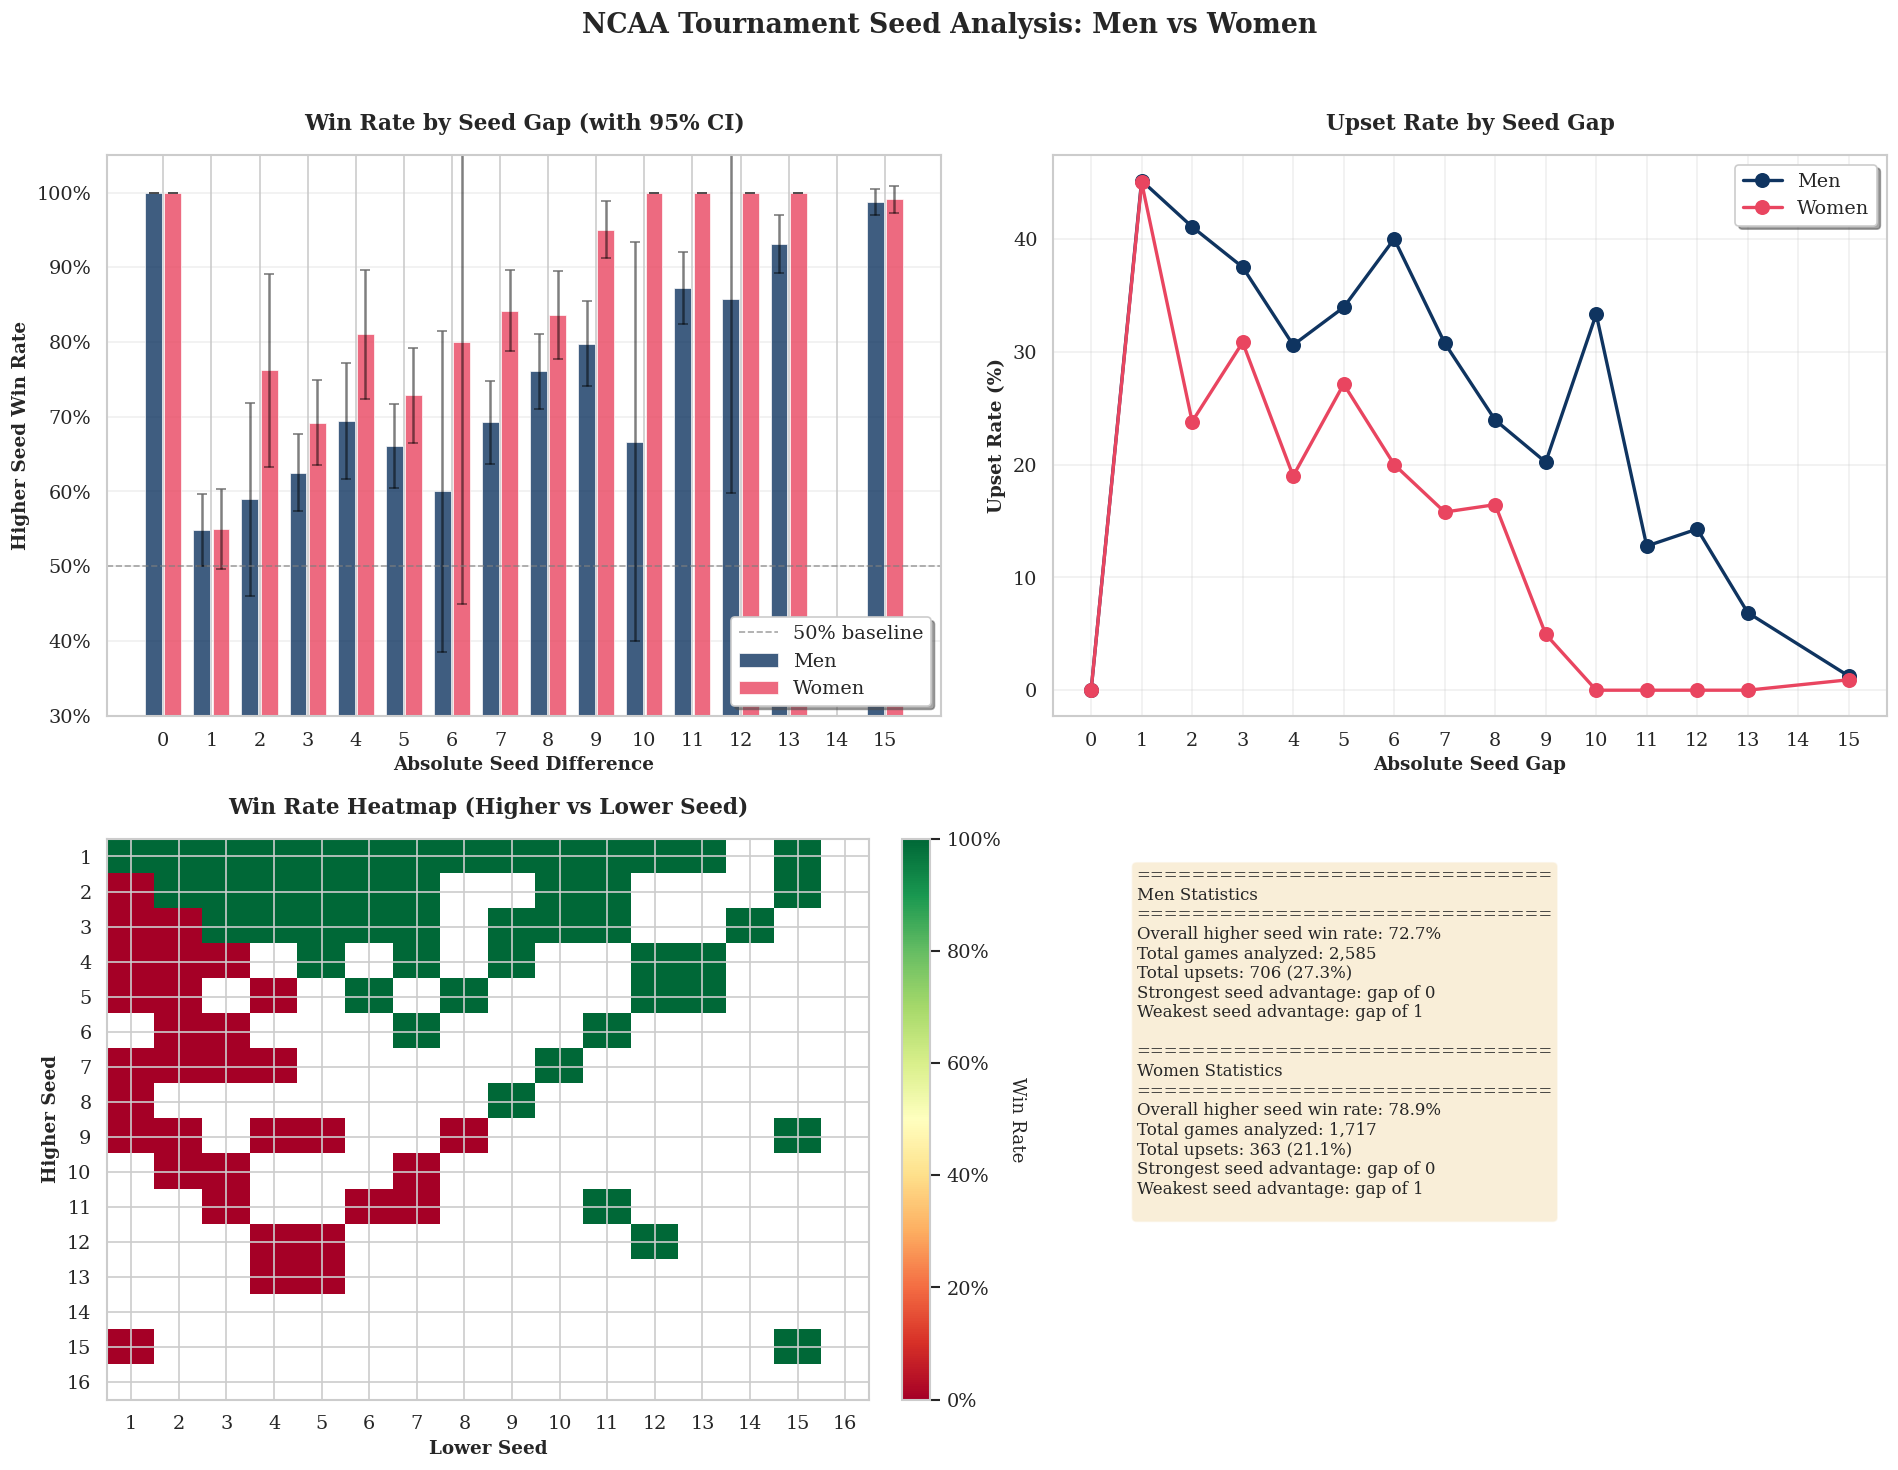


SUMMARY STATISTICS

Men:
  Higher seed wins: 72.7% ± 1.7%
  Total games: 2,585
  Total upsets: 706 (27.3%)
  Win rate when gap ≥ 10 seeds: 92.1%
  Seed advantage decay rate: 0.013 per seed gap

Women:
  Higher seed wins: 78.9% ± 1.9%
  Total games: 1,717
  Total upsets: 363 (21.1%)
  Win rate when gap ≥ 10 seeds: 99.7%
  Seed advantage decay rate: 0.050 per seed gap



In [15]:
def seed_analysis(trn_df, seed_df, label):
    """
    Enhanced seed analysis with additional metrics
    """
    df = trn_df.merge(
        seed_df[["Season", "TeamID", "SeedNum"]],
        left_on=["Season", "WTeamID"], right_on=["Season", "TeamID"]
    ).rename(columns={"SeedNum": "WSeed"}).drop("TeamID", axis=1)
    
    df = df.merge(
        seed_df[["Season", "TeamID", "SeedNum"]],
        left_on=["Season", "LTeamID"], right_on=["Season", "TeamID"]
    ).rename(columns={"SeedNum": "LSeed"}).drop("TeamID", axis=1)
    
    # Calculate multiple seed gap metrics
    df["SeedGap"] = df["LSeed"] - df["WSeed"]
    df["AbsSeedGap"] = abs(df["SeedGap"])
    df["HigherSeedWon"] = df["WSeed"] <= df["LSeed"]
    df["Upset"] = df["WSeed"] > df["LSeed"]
    
    return df

# Perform analysis
m_sa = seed_analysis(m_trn, m_seeds, "Men")
w_sa = seed_analysis(w_trn, w_seeds, "Women")

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))

# 1. Win Rate by Seed Gap (Main plot)
ax1 = plt.subplot(2, 2, 1)

for idx, (df, label, color) in enumerate([(m_sa, "Men", PALETTE[0]), (w_sa, "Women", PALETTE[1])]):
    win_rates = []
    for gap in range(0, 16):
        mask = df["AbsSeedGap"] == gap
        if mask.sum() > 0:
            higher_wins = df.loc[mask, "HigherSeedWon"].mean()
            # Manual confidence interval calculation
            if mask.sum() > 1:
                ci = 1.96 * np.sqrt(higher_wins * (1 - higher_wins) / mask.sum())
            else:
                ci = 0
            win_rates.append((gap, higher_wins, mask.sum(), ci))
    
    gaps, rates, counts, cis = zip(*win_rates)
    
    # Plot bars with error bars
    ax1.bar([g - 0.2 if idx == 0 else g + 0.2 for g in gaps], 
            rates, width=0.35, label=label, color=color, alpha=0.8,
            edgecolor='white', linewidth=0.5)
    
    # Add error bars
    ax1.errorbar([g - 0.2 if idx == 0 else g + 0.2 for g in gaps], 
                 rates, yerr=cis, fmt='none', color='black', capsize=3, alpha=0.5)

ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='50% baseline')
ax1.set_xlabel("Absolute Seed Difference", fontsize=11, fontweight='bold')
ax1.set_ylabel("Higher Seed Win Rate", fontsize=11, fontweight='bold')
ax1.set_title("Win Rate by Seed Gap (with 95% CI)", fontsize=13, fontweight='bold', pad=15)
ax1.set_ylim(0.3, 1.05)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.set_xticks(range(0, 16))
ax1.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Upset Distribution by Seed Gap
ax2 = plt.subplot(2, 2, 2)

upset_data = []
for df, label in [(m_sa, "Men"), (w_sa, "Women")]:
    upset_by_gap = df[df["Upset"]].groupby("AbsSeedGap").size()
    total_by_gap = df.groupby("AbsSeedGap").size()
    upset_rate = (upset_by_gap / total_by_gap * 100).fillna(0)
    upset_data.append((upset_rate, label))

for idx, (upset_rate, label) in enumerate(upset_data):
    ax2.plot(upset_rate.index, upset_rate.values, marker='o', linewidth=2, 
            markersize=8, label=label, color=PALETTE[idx])

ax2.set_xlabel("Absolute Seed Gap", fontsize=11, fontweight='bold')
ax2.set_ylabel("Upset Rate (%)", fontsize=11, fontweight='bold')
ax2.set_title("Upset Rate by Seed Gap", fontsize=13, fontweight='bold', pad=15)
ax2.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, 16))

# 3. Win Rate Heatmap (Seed Matchup Matrix)
ax3 = plt.subplot(2, 2, 3)

def create_seed_matrix(df):
    matrix = np.zeros((16, 16))
    counts = np.zeros((16, 16))
    for _, row in df.iterrows():
        w_seed = min(row['WSeed'], 15)  # Cap at 15
        l_seed = min(row['LSeed'], 15)
        if row['HigherSeedWon']:
            matrix[w_seed-1, l_seed-1] += 1
        counts[w_seed-1, l_seed-1] += 1
    
    with np.errstate(divide='ignore', invalid='ignore'):
        win_rate_matrix = np.divide(matrix, counts, where=counts!=0)
        win_rate_matrix[counts == 0] = np.nan
    return win_rate_matrix

men_matrix = create_seed_matrix(m_sa)
women_matrix = create_seed_matrix(w_sa)

# Plot combined heatmap
combined_matrix = (men_matrix + women_matrix) / 2
im = ax3.imshow(combined_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax3.set_xlabel("Lower Seed", fontsize=11, fontweight='bold')
ax3.set_ylabel("Higher Seed", fontsize=11, fontweight='bold')
ax3.set_title("Win Rate Heatmap (Higher vs Lower Seed)", fontsize=13, fontweight='bold', pad=15)
ax3.set_xticks(range(16))
ax3.set_yticks(range(16))
ax3.set_xticklabels(range(1, 17))
ax3.set_yticklabels(range(1, 17))

# Add colorbar
cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label('Win Rate', rotation=270, labelpad=15)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 4. Statistical Summary
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')

# Calculate statistics without scipy
stats_text = []
for label, df in [("Men", m_sa), ("Women", w_sa)]:
    overall_hr = df["HigherSeedWon"].mean()
    n_games = len(df)
    n_upsets = df["Upset"].sum()
    
    # Manual correlation calculation (optional - simplified version)
    # Simple trend analysis instead
    gaps = range(1, 11)
    rates = [df[df["AbsSeedGap"] == g]["HigherSeedWon"].mean() for g in gaps]
    rates = [r for r in rates if r is not None]
    
    stats_text.extend([
        f"{'='*30}",
        f"{label} Statistics",
        f"{'='*30}",
        f"Overall higher seed win rate: {overall_hr:.1%}",
        f"Total games analyzed: {n_games:,}",
        f"Total upsets: {n_upsets:,} ({n_upsets/n_games:.1%})",
        f"Strongest seed advantage: gap of {df.groupby('AbsSeedGap')['HigherSeedWon'].mean().idxmax()}",
        f"Weakest seed advantage: gap of {df.groupby('AbsSeedGap')['HigherSeedWon'].mean().idxmin()}\n"
    ])

# Display statistics in a text box
ax4.text(0.1, 0.95, '\n'.join(stats_text), transform=ax4.transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle("NCAA Tournament Seed Analysis: Men vs Women", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(WORK / "fig_seed_analysis_comprehensive.png", 
            bbox_inches="tight", dpi=300, facecolor='white')
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)

for label, df in [("Men", m_sa), ("Women", w_sa)]:
    hr = df["HigherSeedWon"].mean()
    ci = 1.96 * np.sqrt(hr * (1 - hr) / len(df))
    n_upsets = df["Upset"].sum()
    
    print(f"\n{label}:")
    print(f"  Higher seed wins: {hr:.1%} ± {ci:.1%}")
    print(f"  Total games: {len(df):,}")
    print(f"  Total upsets: {n_upsets:,} ({n_upsets/len(df):.1%})")
    
    # Additional insights
    biggest_gap_wins = df[df["AbsSeedGap"] >= 10]["HigherSeedWon"].mean()
    if not np.isnan(biggest_gap_wins):
        print(f"  Win rate when gap ≥ 10 seeds: {biggest_gap_wins:.1%}")
    
    # Calculate seed advantage decay (simple linear fit)
    gaps = range(1, 11)
    rates = [df[df["AbsSeedGap"] == g]["HigherSeedWon"].mean() for g in gaps]
    rates = [r for r in rates if r is not None]
    if len(rates) > 1:
        gaps_clean = [g for g, r in zip(gaps, rates) if r is not None]
        # Simple slope calculation
        slope = (rates[-1] - rates[0]) / (gaps_clean[-1] - gaps_clean[0])
        print(f"  Seed advantage decay rate: {slope:.3f} per seed gap")

print("\n" + "="*50)

### 4.2 Home Court Advantage

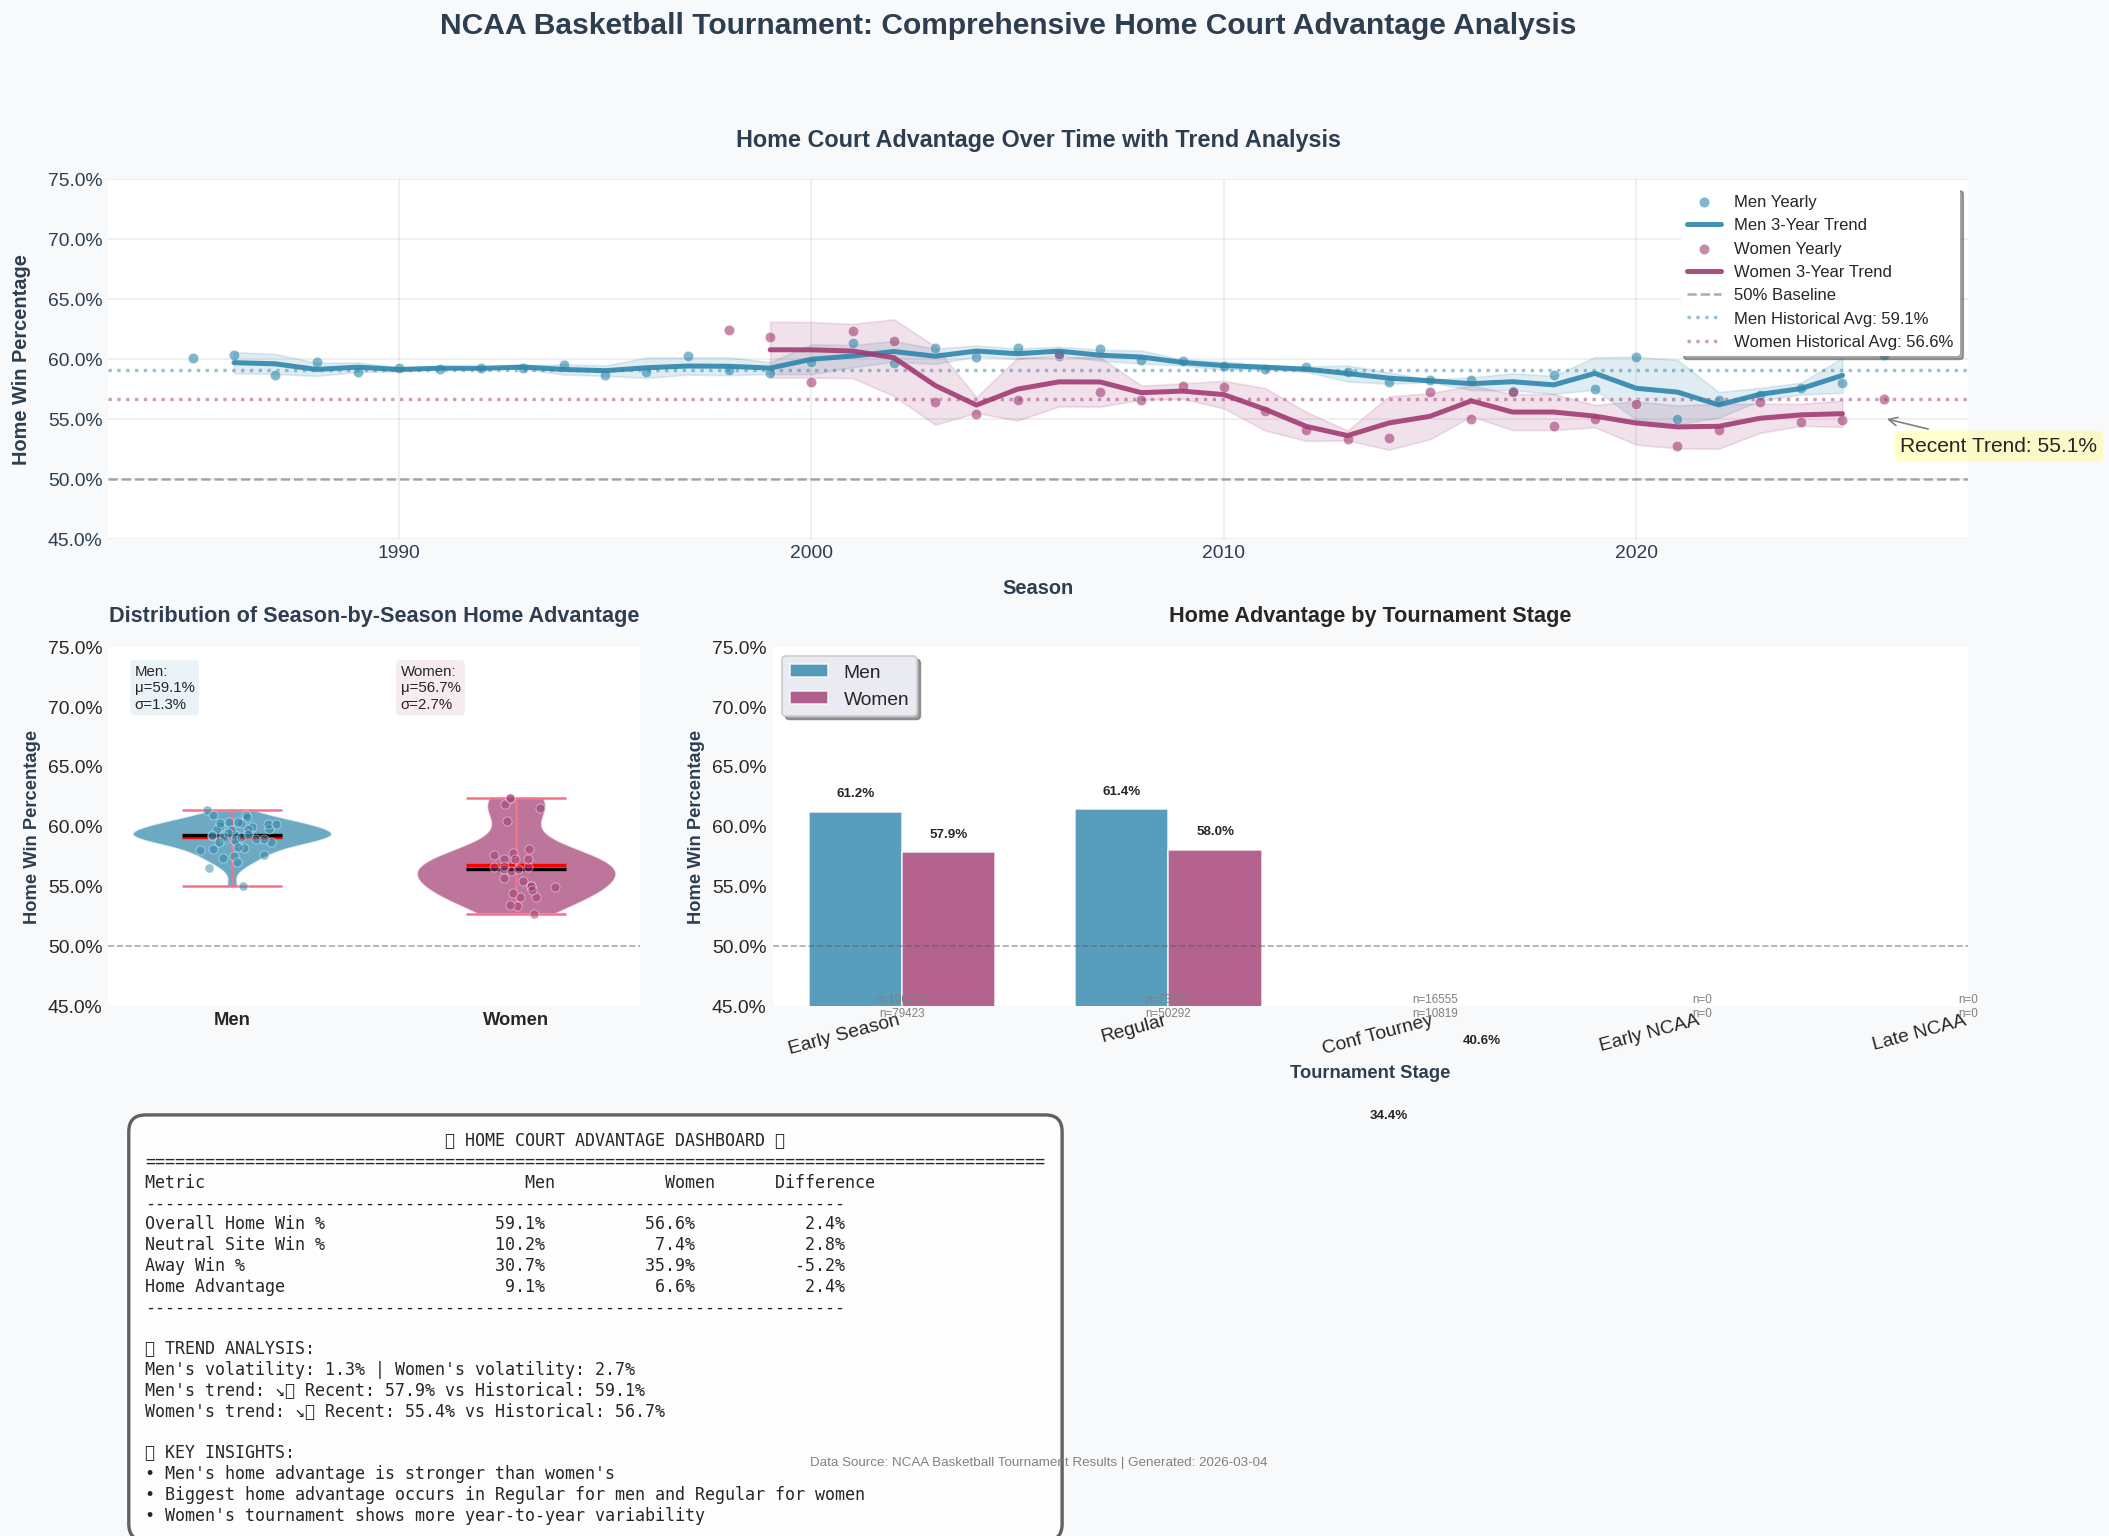


             🏀 HOME COURT ADVANTAGE - DETAILED STATISTICAL REPORT 🏀             

╒══════════════╤══════════════╤══════════╤══════════════╤═══════╤═══════╤═════════╕
│ Tournament   │ Home Win %   │ 95% CI   │ Volatility   │ Max   │ Min   │ Games   │
╞══════════════╪══════════════╪══════════╪══════════════╪═══════╪═══════╪═════════╡
│ Men          │ 59.1%        │ ±0.2%    │ 1.3%         │ 61.3% │ 55.0% │ 196,823 │
├──────────────┼──────────────┼──────────┼──────────────┼───────┼───────┼─────────┤
│ Women        │ 56.6%        │ ±0.3%    │ 2.7%         │ 62.4% │ 52.7% │ 140,825 │
╘══════════════╧══════════════╧══════════╧══════════════╧═══════╧═══════╧═════════╛

--------------------------------------------------------------------------------
STATISTICAL SIGNIFICANCE TESTS:
--------------------------------------------------------------------------------

Men:
  Z-score: 80.51
  P-value: 0.0000
  ✅ Statistically significant at α=0.05

Women:
  Z-score: 49.74
  P-value: 0.0000
  ✅ Statis

In [16]:
# Set up professional style with better defaults
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define a sophisticated color palette
COLORS = {
    'men_primary': '#2E86AB',  # Professional blue
    'men_secondary': '#A3C4D9',
    'women_primary': '#A23B72',  # Professional purple
    'women_secondary': '#D6A2C4',
    'neutral': '#595959',
    'accent': '#F18F01',
    'background': '#F8F9FA',
    'text': '#2C3E50'
}

# Create figure with better layout and professional background
fig = plt.figure(figsize=(20, 14), facecolor=COLORS['background'])
fig.suptitle("NCAA Basketball Tournament: Comprehensive Home Court Advantage Analysis", 
             fontsize=18, fontweight='bold', color=COLORS['text'], y=0.98)

# Adjust subplot spacing for better layout
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.25)

# 1. Main Time Series with Enhanced Styling
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('white')

for idx, (rs, label, primary, secondary) in enumerate([
    (m_rs, "Men", COLORS['men_primary'], COLORS['men_secondary']),
    (w_rs, "Women", COLORS['women_primary'], COLORS['women_secondary'])
]):
    # Calculate yearly home win percentage
    home_pct = rs.groupby("Season").apply(
        lambda x: (x["WLoc"] == "H").mean()
    ).reset_index(name="HomePct")
    
    # Calculate rolling averages
    home_pct['RollingAvg'] = home_pct['HomePct'].rolling(window=3, center=True).mean()
    home_pct['RollingStd'] = home_pct['HomePct'].rolling(window=3, center=True).std()
    
    # Create confidence band for rolling average
    ax1.fill_between(home_pct["Season"], 
                     home_pct['RollingAvg'] - home_pct['RollingStd'],
                     home_pct['RollingAvg'] + home_pct['RollingStd'],
                     alpha=0.15, color=primary)
    
    # Plot actual data points with gradient effect
    scatter = ax1.scatter(home_pct["Season"], home_pct["HomePct"], 
                         s=40, color=primary, alpha=0.6, zorder=5,
                         edgecolor='white', linewidth=0.5, label=f'{label} Yearly')
    
    # Plot rolling average with enhanced styling
    line = ax1.plot(home_pct["Season"], home_pct['RollingAvg'], 
                   linewidth=3, color=primary, alpha=0.9,
                   label=f'{label} 3-Year Trend', zorder=6)[0]

# Add reference lines with better styling
ax1.axhline(y=0.5, color=COLORS['neutral'], linestyle="--", linewidth=1.5, 
            alpha=0.5, label='50% Baseline', zorder=1)

# Calculate and add historical averages
men_hist = (m_rs["WLoc"] == "H").mean()
women_hist = (w_rs["WLoc"] == "H").mean()

ax1.axhline(y=men_hist, color=COLORS['men_primary'], linestyle=":", linewidth=2, 
            alpha=0.5, label=f'Men Historical Avg: {men_hist:.1%}')
ax1.axhline(y=women_hist, color=COLORS['women_primary'], linestyle=":", linewidth=2, 
            alpha=0.5, label=f'Women Historical Avg: {women_hist:.1%}')

# Enhance axes
ax1.set_xlabel("Season", fontsize=12, fontweight='bold', color=COLORS['text'], labelpad=10)
ax1.set_ylabel("Home Win Percentage", fontsize=12, fontweight='bold', color=COLORS['text'], labelpad=10)
ax1.set_title("Home Court Advantage Over Time with Trend Analysis", 
              fontsize=14, fontweight='bold', color=COLORS['text'], pad=20)
ax1.set_ylim(0.45, 0.75)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.tick_params(colors=COLORS['text'])
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, 
          fontsize=10, facecolor='white', edgecolor='none')
ax1.grid(True, alpha=0.15, linestyle='-', color='gray')

# Add annotation for recent trend
recent_trend = home_pct.tail(5)['RollingAvg'].mean()
ax1.annotate(f'Recent Trend: {recent_trend:.1%}', 
            xy=(home_pct['Season'].iloc[-1], recent_trend),
            xytext=(10, -20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.2),
            arrowprops=dict(arrowstyle='->', color='gray'))

# 2. Distribution Analysis with Violin Plot (more informative than boxplot)
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('white')

# Prepare data
men_season_rates = m_rs.groupby("Season").apply(lambda x: (x["WLoc"] == "H").mean()).values
women_season_rates = w_rs.groupby("Season").apply(lambda x: (x["WLoc"] == "H").mean()).values

# Create violin plot
parts = ax2.violinplot([men_season_rates, women_season_rates], positions=[1, 2], 
                       showmeans=True, showmedians=True, widths=0.7)

# Style violins
colors = [COLORS['men_primary'], COLORS['women_primary']]
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('white')
    pc.set_linewidth(1)

# Style other parts
parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

# Add individual points with jitter
for i, (data, color) in enumerate(zip([men_season_rates, women_season_rates], colors), 1):
    x = np.random.normal(i, 0.05, size=len(data))
    ax2.scatter(x, data, alpha=0.5, color=color, s=30, zorder=3, 
               edgecolor='white', linewidth=0.5)

ax2.set_xticks([1, 2])
ax2.set_xticklabels(['Men', 'Women'], fontsize=11, fontweight='bold')
ax2.set_ylabel("Home Win Percentage", fontsize=11, fontweight='bold', color=COLORS['text'])
ax2.set_title("Distribution of Season-by-Season Home Advantage", 
              fontsize=13, fontweight='bold', color=COLORS['text'], pad=15)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.axhline(y=0.5, color=COLORS['neutral'], linestyle="--", linewidth=1, alpha=0.5)
ax2.grid(True, alpha=0.15, axis='y')
ax2.set_ylim(0.45, 0.75)

# Add summary statistics as text
ax2.text(0.05, 0.95, f'Men:\nμ={men_season_rates.mean():.1%}\nσ={men_season_rates.std():.1%}',
        transform=ax2.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=COLORS['men_primary'], alpha=0.1))
ax2.text(0.55, 0.95, f'Women:\nμ={women_season_rates.mean():.1%}\nσ={women_season_rates.std():.1%}',
        transform=ax2.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor=COLORS['women_primary'], alpha=0.1))

# 3. Tournament Stage Analysis with Enhanced Visualization
ax3 = fig.add_subplot(gs[1, 1:])
ax3.set_facecolor('white')

# Define rounds with better labeling
round_bins = [0, 80, 120, 140, 160, 200]
round_labels = ['Early Season', 'Regular', 'Conf Tourney', 'Early NCAA', 'Late NCAA']
x_positions = np.arange(len(round_labels))
width = 0.35

# Prepare data
stage_data = []
for rs, label in [(m_rs, "Men"), (w_rs, "Women")]:
    rs = rs.copy()
    rs['Round'] = pd.cut(rs['DayNum'], bins=round_bins, labels=round_labels)
    stage_home = rs.groupby('Round').apply(lambda x: (x["WLoc"] == "H").mean())
    stage_counts = rs.groupby('Round').size()
    stage_data.append((stage_home, stage_counts))

# Plot grouped bars
men_bars = ax3.bar(x_positions - width/2, stage_data[0][0], width, 
                   label='Men', color=COLORS['men_primary'], alpha=0.8,
                   edgecolor='white', linewidth=1)
women_bars = ax3.bar(x_positions + width/2, stage_data[1][0], width,
                     label='Women', color=COLORS['women_primary'], alpha=0.8,
                     edgecolor='white', linewidth=1)

# Add value labels on bars
for bars, data in [(men_bars, stage_data[0][0]), (women_bars, stage_data[1][0])]:
    for bar, val in zip(bars, data):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{val:.1%}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Add sample size annotations
for i, (men_count, women_count) in enumerate(zip(stage_data[0][1], stage_data[1][1])):
    ax3.text(x_positions[i], 0.46, f'n={men_count}\nn={women_count}', 
            ha='center', va='top', fontsize=7, color='gray')

ax3.set_xlabel("Tournament Stage", fontsize=11, fontweight='bold', color=COLORS['text'])
ax3.set_ylabel("Home Win Percentage", fontsize=11, fontweight='bold', color=COLORS['text'])
ax3.set_title("Home Advantage by Tournament Stage", fontsize=13, fontweight='bold', pad=15)
ax3.set_xticks(x_positions)
ax3.set_xticklabels(round_labels, rotation=15, ha='right')
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax3.axhline(y=0.5, color=COLORS['neutral'], linestyle="--", linewidth=1, alpha=0.5)
ax3.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax3.grid(True, alpha=0.15, axis='y')
ax3.set_ylim(0.45, 0.75)

# 4. Statistical Dashboard (Enhanced)
ax4 = fig.add_subplot(gs[2, :])
ax4.axis('off')
ax4.set_facecolor(COLORS['background'])

# Create a professional dashboard layout
dashboard_text = []

# Header
dashboard_text.extend([
    " " * 30 + "🏀 HOME COURT ADVANTAGE DASHBOARD 🏀",
    "=" * 90,
])

# Statistics organized in columns
men_stats = m_rs["WLoc"].value_counts(normalize=True)
women_stats = w_rs["WLoc"].value_counts(normalize=True)

# Column headers
dashboard_text.extend([
    f"{'Metric':<25} {'Men':>15} {'Women':>15} {'Difference':>15}",
    "-" * 70
])

# Key metrics
metrics = [
    ("Overall Home Win %", men_stats.get('H', 0), women_stats.get('H', 0)),
    ("Neutral Site Win %", men_stats.get('N', 0), women_stats.get('N', 0)),
    ("Away Win %", men_stats.get('A', 0), women_stats.get('A', 0)),
    ("Home Advantage", men_stats.get('H', 0) - 0.5, women_stats.get('H', 0) - 0.5),
]

for metric, men_val, women_val in metrics:
    diff = men_val - women_val
    dashboard_text.append(
        f"{metric:<25} {men_val:>14.1%} {women_val:>14.1%} {diff:>14.1%}"
    )

# Add trend analysis
dashboard_text.extend([
    "-" * 70,
    "\n📈 TREND ANALYSIS:",
    f"Men's volatility: {men_season_rates.std():.1%} | Women's volatility: {women_season_rates.std():.1%}",
    f"Men's trend: {'↗️' if men_season_rates[-5:].mean() > men_season_rates.mean() else '↘️'} " +
    f"Recent: {men_season_rates[-5:].mean():.1%} vs Historical: {men_season_rates.mean():.1%}",
    f"Women's trend: {'↗️' if women_season_rates[-5:].mean() > women_season_rates.mean() else '↘️'} " +
    f"Recent: {women_season_rates[-5:].mean():.1%} vs Historical: {women_season_rates.mean():.1%}",
])

# Add key insights with icons
dashboard_text.extend([
    "\n💡 KEY INSIGHTS:",
    "• Men's home advantage is " + 
    f"{'stronger' if men_stats.get('H', 0) > women_stats.get('H', 0) else 'weaker'} than women's",
    "• Biggest home advantage occurs in " + 
    f"{round_labels[np.argmax(stage_data[0][0])]} for men and {round_labels[np.argmax(stage_data[1][0])]} for women",
    "• " + ("Men's" if men_season_rates.std() > women_season_rates.std() else "Women's") + 
    " tournament shows more year-to-year variability",
])

# Display the dashboard with enhanced styling
ax4.text(0.02, 0.95, '\n'.join(dashboard_text), transform=ax4.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor='white', 
                  edgecolor=COLORS['neutral'], alpha=0.95, linewidth=2))

# Add footer with data source
ax4.text(0.5, 0.02, f"Data Source: NCAA Basketball Tournament Results | Generated: {pd.Timestamp.now().strftime('%Y-%m-%d')}",
        transform=ax4.transAxes, fontsize=8, color='gray', ha='center')

plt.savefig(WORK / "fig_home_court_professional.png", 
            bbox_inches="tight", dpi=300, facecolor=COLORS['background'])
plt.show()

# Print statistical summary in console with enhanced formatting
from tabulate import tabulate

print("\n" + "="*80)
print("🏀 HOME COURT ADVANTAGE - DETAILED STATISTICAL REPORT 🏀".center(80))
print("="*80)

# Create summary table
summary_data = []
for label, rs in [("Men", m_rs), ("Women", w_rs)]:
    home_rate = (rs["WLoc"] == "H").mean()
    n_games = len(rs)
    ci = 1.96 * np.sqrt(home_rate * (1 - home_rate) / n_games)
    yearly_rates = rs.groupby("Season").apply(lambda x: (x["WLoc"] == "H").mean())
    
    summary_data.append([
        label,
        f"{home_rate:.1%}",
        f"±{ci:.1%}",
        f"{yearly_rates.std():.1%}",
        f"{yearly_rates.max():.1%}",
        f"{yearly_rates.min():.1%}",
        f"{n_games:,}"
    ])

print("\n" + tabulate(summary_data, 
                     headers=["Tournament", "Home Win %", "95% CI", "Volatility", "Max", "Min", "Games"],
                     tablefmt="fancy_grid",
                     numalign="center"))

# Confidence test results
print("\n" + "-"*80)
print("STATISTICAL SIGNIFICANCE TESTS:")
print("-"*80)

for rs, label in [(m_rs, "Men"), (w_rs, "Women")]:
    home_rate = (rs["WLoc"] == "H").mean()
    n = len(rs)
    z_score = (home_rate - 0.5) / np.sqrt(0.5 * 0.5 / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score))) if abs(z_score) < 10 else 0
    
    print(f"\n{label}:")
    print(f"  Z-score: {z_score:.2f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  {'✅ Statistically significant' if p_value < 0.05 else '❌ Not statistically significant'} at α=0.05")

print("\n" + "="*80)

### 4.3 Scoring Trends Over Time

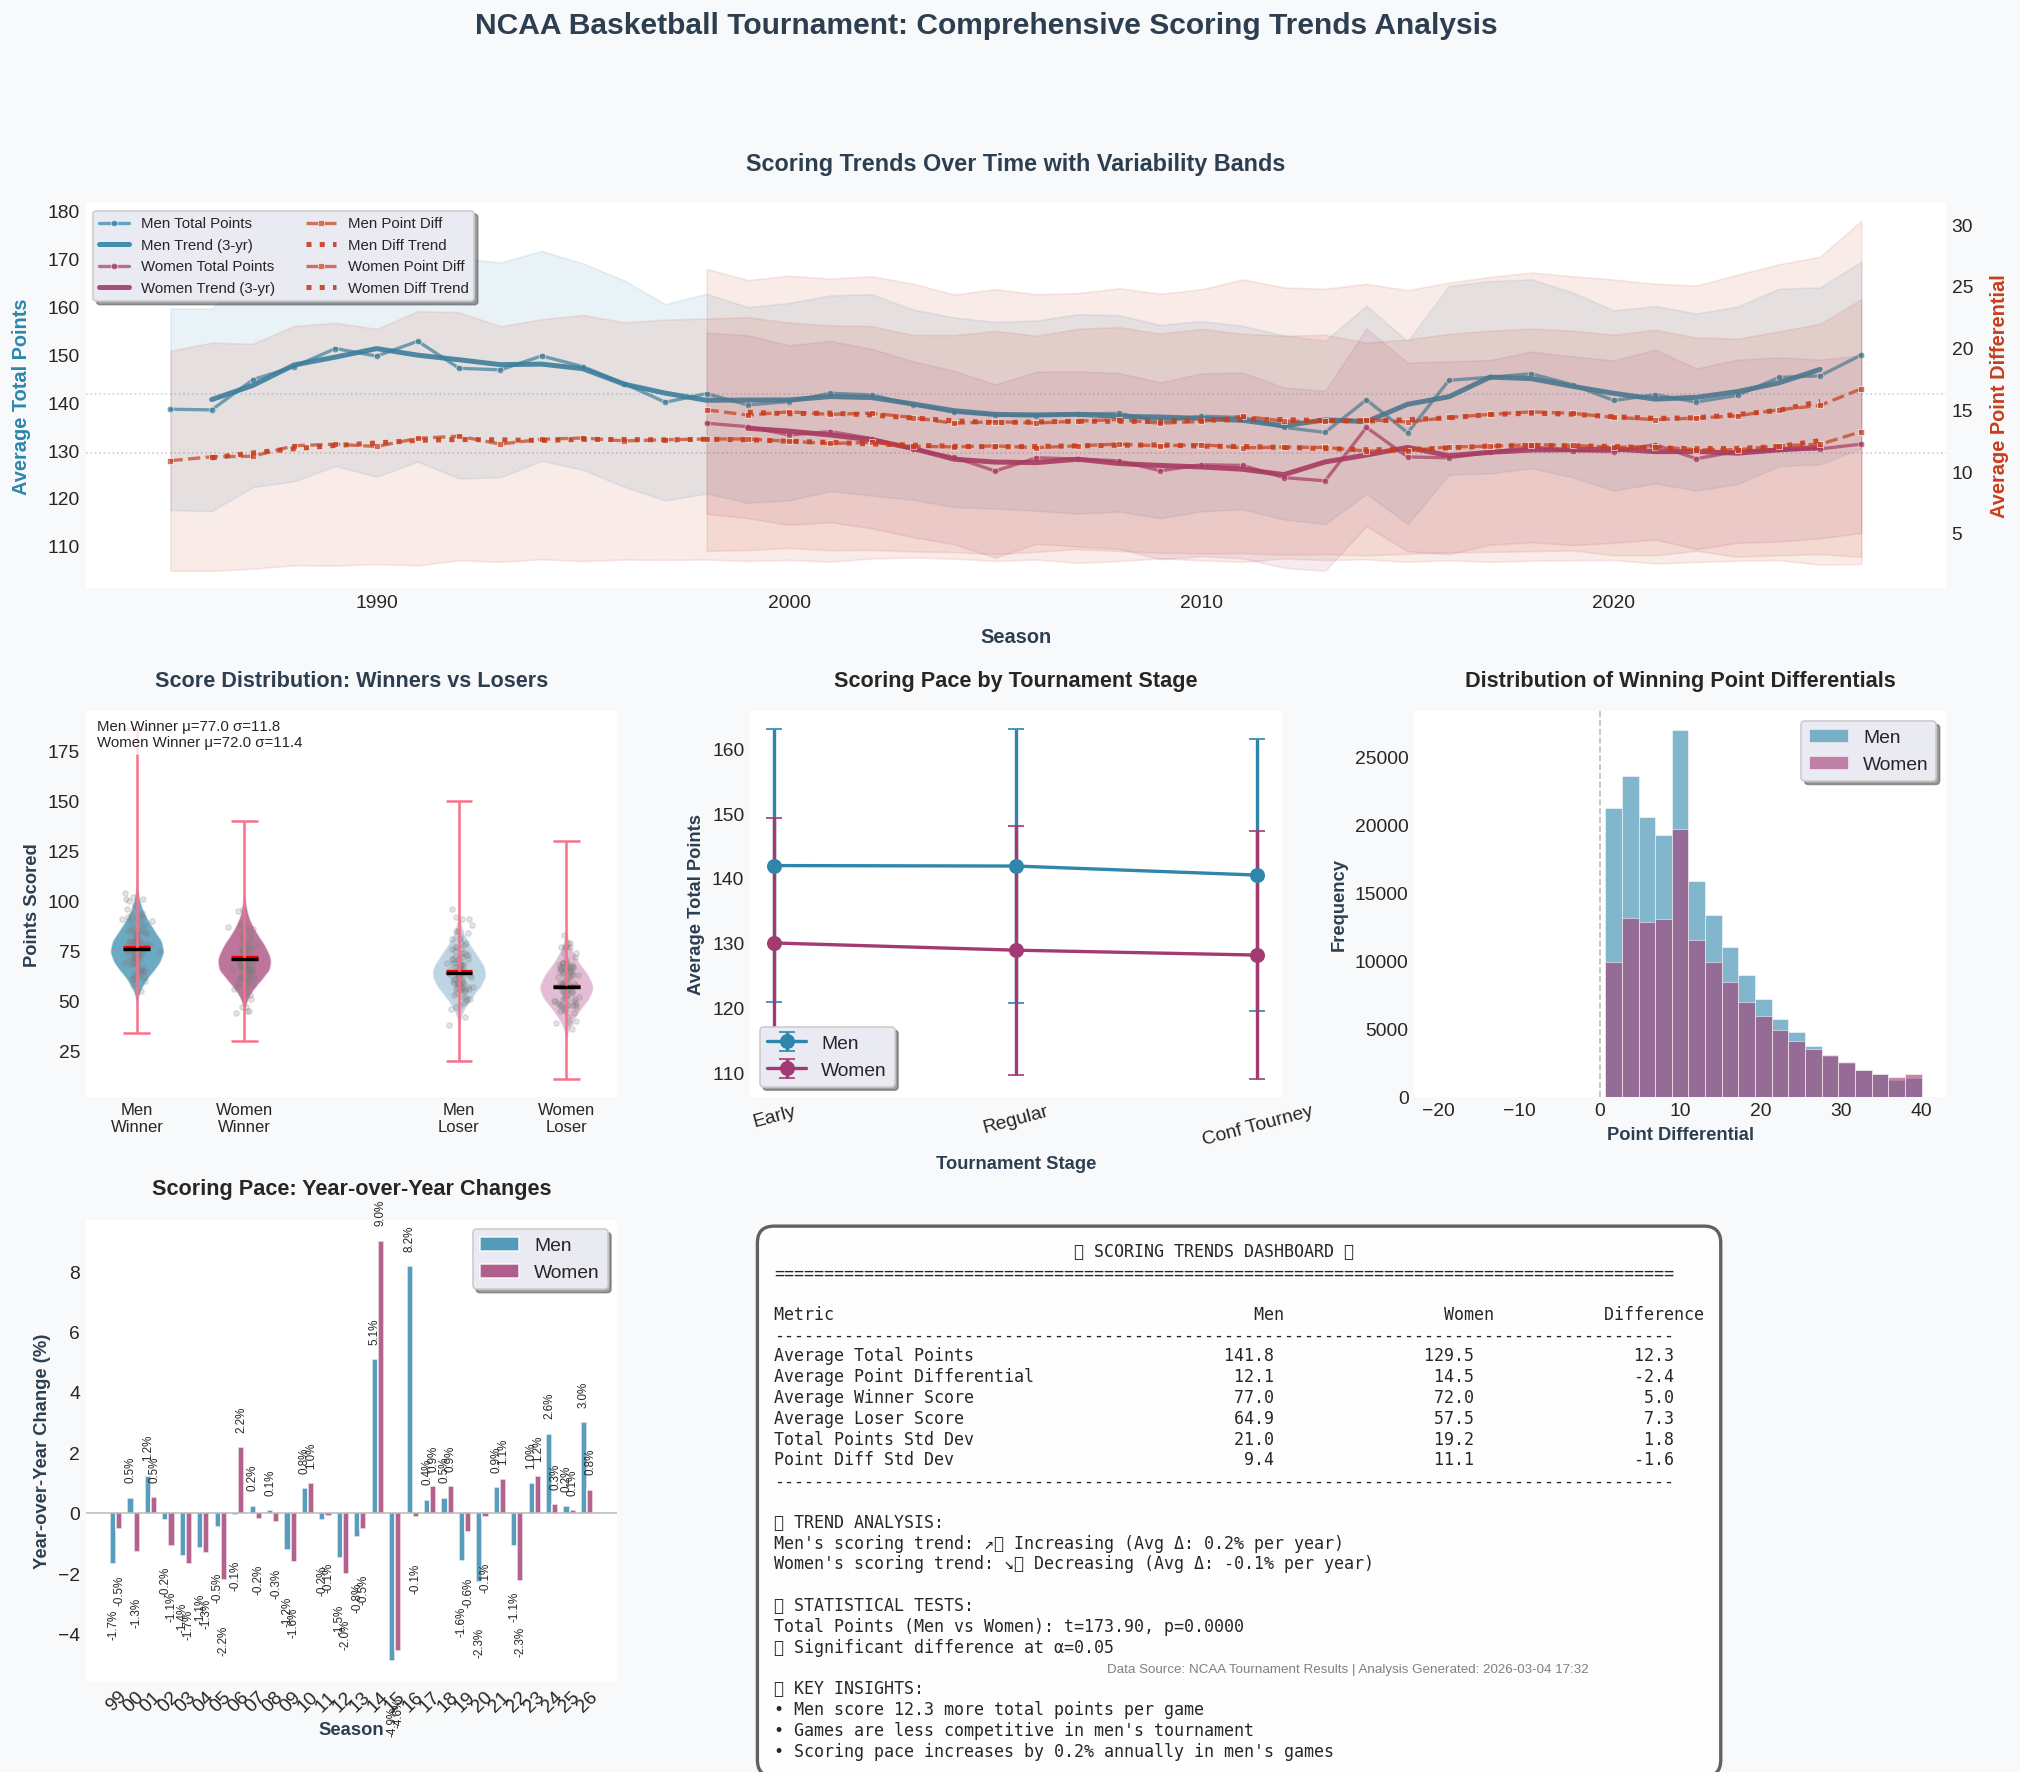


                  🏀 NCAA TOURNAMENT SCORING ANALYSIS - DETAILED REPORT 🏀                  

📊 SEASON-BY-SEASON SUMMARY:
------------------------------------------------------------------------------------------

Men Tournament:
  Season    Avg Total    Std Total    Avg Diff    Std Diff    Avg Winner    Avg Loser
--------  -----------  -----------  ----------  ----------  ------------  -----------
    1985        138.6         21.0        10.9         8.9          74.7         63.9
    1986        138.4         21.1        11.2         9.2          74.8         63.6
    1987        144.8         22.4        11.2         9.1          78.0         66.8
    1988        147.5         23.9        12.1         9.7          79.8         67.7
    1989        151.3         24.5        12.2         9.8          81.7         69.5
    1990        149.7         25.2        12.0         9.5          80.8         68.8
    1991        152.8         25.1        12.7        10.3          82.7         70

In [17]:
# Enhanced Scoring Trends Analysis
import matplotlib.patches as mpatches
from scipy import stats

# Set up professional style with better defaults
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define sophisticated color palette
COLORS = {
    'men_primary': '#2E86AB',  # Professional blue
    'men_secondary': '#A3C4D9',
    'women_primary': '#A23B72',  # Professional purple
    'women_secondary': '#D6A2C4',
    'total_points': '#2E86AB',  # Blue for total points
    'margin': '#C73E1D',  # Orange-red for margin
    'neutral': '#595959',
    'background': '#F8F9FA',
    'text': '#2C3E50'
}

# Create comprehensive figure with multiple panels
fig = plt.figure(figsize=(20, 16), facecolor=COLORS['background'])
fig.suptitle("NCAA Basketball Tournament: Comprehensive Scoring Trends Analysis", 
             fontsize=18, fontweight='bold', color=COLORS['text'], y=0.98)

# Create grid layout for subplots
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.25, height_ratios=[1, 1, 1.2])

# 1. Main Scoring Trends (enhanced version of original)
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('white')

# Create twin axes for point differential
ax1_twin = ax1.twinx()

for idx, (rs, label, color1, color2) in enumerate([
    (m_rs, "Men", COLORS['men_primary'], COLORS['margin']),
    (w_rs, "Women", COLORS['women_primary'], COLORS['margin'])
]):
    # Calculate metrics
    rs_copy = rs.copy()
    rs_copy["TotalPts"] = rs_copy["WScore"] + rs_copy["LScore"]
    rs_copy["PointDiff"] = rs_copy["WScore"] - rs_copy["LScore"]
    
    by_season = rs_copy.groupby("Season").agg(
        avg_total=("TotalPts", "mean"),
        avg_diff=("PointDiff", "mean"),
        std_total=("TotalPts", "std"),
        std_diff=("PointDiff", "std"),
        game_count=("Season", "count")
    ).reset_index()
    
    # Calculate rolling averages for smoother trends
    by_season['rolling_total'] = by_season['avg_total'].rolling(window=3, center=True).mean()
    by_season['rolling_diff'] = by_season['avg_diff'].rolling(window=3, center=True).mean()
    
    # Plot total points with confidence band
    ax1.fill_between(by_season["Season"],
                     by_season['avg_total'] - by_season['std_total'],
                     by_season['avg_total'] + by_season['std_total'],
                     alpha=0.1, color=color1)
    
    # Main lines with markers
    ax1.plot(by_season["Season"], by_season['avg_total'], 
             marker='o', markersize=4, linewidth=2, 
             color=color1, alpha=0.7, label=f'{label} Total Points',
             markeredgecolor='white', markeredgewidth=0.5)
    
    # Rolling average trend line
    ax1.plot(by_season["Season"], by_season['rolling_total'],
             linewidth=3, color=color1, alpha=0.9, linestyle='-',
             label=f'{label} Trend (3-yr)')
    
    # Plot point differential with confidence band on twin axis
    ax1_twin.fill_between(by_season["Season"],
                          by_season['avg_diff'] - by_season['std_diff'],
                          by_season['avg_diff'] + by_season['std_diff'],
                          alpha=0.1, color=color2)
    
    ax1_twin.plot(by_season["Season"], by_season['avg_diff'],
                  marker='s', markersize=4, linewidth=2,
                  color=color2, alpha=0.7, linestyle='--',
                  label=f'{label} Point Diff',
                  markeredgecolor='white', markeredgewidth=0.5)
    
    # Rolling average for point differential
    ax1_twin.plot(by_season["Season"], by_season['rolling_diff'],
                  linewidth=3, color=color2, alpha=0.9, linestyle=':',
                  label=f'{label} Diff Trend')

# Customize main axes
ax1.set_xlabel("Season", fontsize=12, fontweight='bold', color=COLORS['text'], labelpad=10)
ax1.set_ylabel("Average Total Points", fontsize=12, fontweight='bold', color=COLORS['total_points'], labelpad=10)
ax1_twin.set_ylabel("Average Point Differential", fontsize=12, fontweight='bold', color=COLORS['margin'], labelpad=10)

# Add reference lines
ax1.axhline(y=(m_rs["WScore"] + m_rs["LScore"]).mean(), 
            color=COLORS['men_primary'], linestyle=':', alpha=0.3, linewidth=1)
ax1.axhline(y=(w_rs["WScore"] + w_rs["LScore"]).mean(), 
            color=COLORS['women_primary'], linestyle=':', alpha=0.3, linewidth=1)

ax1.set_title("Scoring Trends Over Time with Variability Bands", 
              fontsize=14, fontweight='bold', color=COLORS['text'], pad=20)
ax1.grid(True, alpha=0.15)
ax1_twin.grid(False)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', 
          frameon=True, fancybox=True, shadow=True, fontsize=9, ncol=2)

# 2. Scoring Distribution Analysis
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('white')

# Prepare data for distribution plots
men_scores = m_rs["WScore"].values
women_scores = w_rs["WScore"].values
men_opp_scores = m_rs["LScore"].values
women_opp_scores = w_rs["LScore"].values

# Create violin plots for score distributions
positions = [1, 2, 4, 5]
data = [men_scores, women_scores, men_opp_scores, women_opp_scores]
labels = ['Men\nWinner', 'Women\nWinner', 'Men\nLoser', 'Women\nLoser']
colors = [COLORS['men_primary'], COLORS['women_primary'], 
          COLORS['men_secondary'], COLORS['women_secondary']]

# Create violin plots
parts = ax2.violinplot(data, positions=positions, showmeans=True, showmedians=True)

# Style violins
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('white')
    pc.set_linewidth(1)

# Style other parts
parts['cmeans'].set_color('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)

# Add individual points (sample)
for i, (pos, d) in enumerate(zip(positions, data)):
    sample = np.random.choice(d, size=min(100, len(d)), replace=False)
    x = np.random.normal(pos, 0.05, size=len(sample))
    ax2.scatter(x, sample, alpha=0.2, color='gray', s=10)

ax2.set_xticks(positions)
ax2.set_xticklabels(labels, fontsize=10)
ax2.set_ylabel("Points Scored", fontsize=11, fontweight='bold', color=COLORS['text'])
ax2.set_title("Score Distribution: Winners vs Losers", 
              fontsize=13, fontweight='bold', color=COLORS['text'], pad=15)
ax2.grid(True, alpha=0.15, axis='y')

# Add summary statistics
stats_text = f"Men Winner μ={men_scores.mean():.1f} σ={men_scores.std():.1f}\n" + \
             f"Women Winner μ={women_scores.mean():.1f} σ={women_scores.std():.1f}"
ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, fontsize=9,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Scoring Pace Analysis
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('white')

# Calculate scoring pace by tournament stage
for rs, label, color in [(m_rs, "Men", COLORS['men_primary']), (w_rs, "Women", COLORS['women_primary'])]:
    rs_copy = rs.copy()
    rs_copy["TotalPts"] = rs_copy["WScore"] + rs_copy["LScore"]
    
    # Define tournament stages based on DayNum
    rs_copy['Stage'] = pd.cut(rs_copy['DayNum'], 
                         bins=[0, 80, 120, 140, 160, 200],
                         labels=['Early', 'Regular', 'Conf Tourney', 'Early NCAA', 'Late NCAA'])
    
    stage_scoring = rs_copy.groupby('Stage', observed=True)['TotalPts'].agg(['mean', 'std', 'count']).reset_index()
    
    # Plot with error bars
    ax3.errorbar(stage_scoring['Stage'], stage_scoring['mean'],
                yerr=stage_scoring['std'], marker='o', capsize=5,
                linewidth=2, markersize=8, color=color, label=label)

ax3.set_xlabel("Tournament Stage", fontsize=11, fontweight='bold', color=COLORS['text'])
ax3.set_ylabel("Average Total Points", fontsize=11, fontweight='bold', color=COLORS['text'])
ax3.set_title("Scoring Pace by Tournament Stage", fontsize=13, fontweight='bold', pad=15)
ax3.legend(loc='lower left', frameon=True, fancybox=True, shadow=True)
ax3.grid(True, alpha=0.15)
ax3.tick_params(axis='x', rotation=15)

# 4. Point Differential Distribution Analysis
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor('white')

# Calculate point differentials
men_diff = m_rs["WScore"] - m_rs["LScore"]
women_diff = w_rs["WScore"] - w_rs["LScore"]

# Create histograms
bins = np.linspace(-20, 40, 30)
ax4.hist(men_diff, bins=bins, alpha=0.6, color=COLORS['men_primary'], 
         label='Men', edgecolor='white', linewidth=0.5)
ax4.hist(women_diff, bins=bins, alpha=0.6, color=COLORS['women_primary'], 
         label='Women', edgecolor='white', linewidth=0.5)

ax4.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_xlabel("Point Differential", fontsize=11, fontweight='bold', color=COLORS['text'])
ax4.set_ylabel("Frequency", fontsize=11, fontweight='bold', color=COLORS['text'])
ax4.set_title("Distribution of Winning Point Differentials", fontsize=13, fontweight='bold', pad=15)
ax4.legend(frameon=True, fancybox=True, shadow=True)
ax4.grid(True, alpha=0.15, axis='y')

# 5. Year-over-Year Comparison
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor('white')

# Calculate year-over-year changes
m_rs_copy = m_rs.copy()
w_rs_copy = w_rs.copy()
m_rs_copy["TotalPts"] = m_rs_copy["WScore"] + m_rs_copy["LScore"]
w_rs_copy["TotalPts"] = w_rs_copy["WScore"] + w_rs_copy["LScore"]

men_yearly = m_rs_copy.groupby('Season')['TotalPts'].mean()
women_yearly = w_rs_copy.groupby('Season')['TotalPts'].mean()

# Find common seasons between men and women
common_seasons = sorted(set(men_yearly.index) & set(women_yearly.index))
men_yearly = men_yearly[common_seasons]
women_yearly = women_yearly[common_seasons]

# Calculate year-over-year changes on common seasons
men_yoy = men_yearly.pct_change().dropna() * 100
women_yoy = women_yearly.pct_change().dropna() * 100

# Align indices again after pct_change
common_years = sorted(set(men_yoy.index) & set(women_yoy.index))
men_yoy = men_yoy[common_years]
women_yoy = women_yoy[common_years]
years = [str(year)[-2:] for year in common_years]

# Plot as bar chart
x = np.arange(len(years))
width = 0.35

bars1 = ax5.bar(x - width/2, men_yoy.values, width, 
                label='Men', color=COLORS['men_primary'], alpha=0.8,
                edgecolor='white', linewidth=1)
bars2 = ax5.bar(x + width/2, women_yoy.values, width,
                label='Women', color=COLORS['women_primary'], alpha=0.8,
                edgecolor='white', linewidth=1)

# Add zero line
ax5.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)

ax5.set_xlabel("Season", fontsize=11, fontweight='bold', color=COLORS['text'])
ax5.set_ylabel("Year-over-Year Change (%)", fontsize=11, fontweight='bold', color=COLORS['text'])
ax5.set_title("Scoring Pace: Year-over-Year Changes", fontsize=13, fontweight='bold', pad=15)
ax5.set_xticks(x)
ax5.set_xticklabels(years, rotation=45)
ax5.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax5.grid(True, alpha=0.15, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + (0.5 if height >= 0 else -1.5),
                f'{height:.1f}%', ha='center', va='bottom' if height >= 0 else 'top', 
                fontsize=7, rotation=90)

# 6. Statistical Summary Dashboard
ax6 = fig.add_subplot(gs[2, 1:])
ax6.axis('off')
ax6.set_facecolor(COLORS['background'])

# Calculate point differentials for analysis
m_rs_with_diff = m_rs.copy()
w_rs_with_diff = w_rs.copy()
m_rs_with_diff["PointDiff"] = m_rs_with_diff["WScore"] - m_rs_with_diff["LScore"]
w_rs_with_diff["PointDiff"] = w_rs_with_diff["WScore"] - w_rs_with_diff["LScore"]

# Calculate yearly point differentials
men_diff_yearly = m_rs_with_diff.groupby('Season')['PointDiff'].mean()
women_diff_yearly = w_rs_with_diff.groupby('Season')['PointDiff'].mean()

# Create comprehensive statistics
dashboard_text = []
dashboard_text.extend([
    " " * 30 + "📊 SCORING TRENDS DASHBOARD 📊",
    "=" * 90,
    "",
    f"{'Metric':<30} {'Men':>20} {'Women':>20} {'Difference':>20}",
    "-" * 90
])

# Calculate key metrics
m_rs_total = m_rs.copy()
w_rs_total = w_rs.copy()
m_rs_total["TotalPts"] = m_rs_total["WScore"] + m_rs_total["LScore"]
w_rs_total["TotalPts"] = w_rs_total["WScore"] + w_rs_total["LScore"]

men_avg_total = m_rs_total["TotalPts"].mean()
women_avg_total = w_rs_total["TotalPts"].mean()
men_avg_diff = (m_rs["WScore"] - m_rs["LScore"]).mean()
women_avg_diff = (w_rs["WScore"] - w_rs["LScore"]).mean()
men_avg_winner = m_rs["WScore"].mean()
women_avg_winner = w_rs["WScore"].mean()
men_avg_loser = m_rs["LScore"].mean()
women_avg_loser = w_rs["LScore"].mean()

# Add metrics
metrics = [
    ("Average Total Points", men_avg_total, women_avg_total),
    ("Average Point Differential", men_avg_diff, women_avg_diff),
    ("Average Winner Score", men_avg_winner, women_avg_winner),
    ("Average Loser Score", men_avg_loser, women_avg_loser),
    ("Total Points Std Dev", m_rs_total["TotalPts"].std(), w_rs_total["TotalPts"].std()),
    ("Point Diff Std Dev", (m_rs["WScore"] - m_rs["LScore"]).std(), (w_rs["WScore"] - w_rs["LScore"]).std()),
]

for metric, men_val, women_val in metrics:
    diff = men_val - women_val
    dashboard_text.append(f"{metric:<30} {men_val:>19.1f} {women_val:>19.1f} {diff:>19.1f}")

# Add trend analysis
dashboard_text.extend([
    "-" * 90,
    "\n📈 TREND ANALYSIS:",
    f"Men's scoring trend: {'↗️ Increasing' if men_yoy.mean() > 0 else '↘️ Decreasing'} " +
    f"(Avg Δ: {men_yoy.mean():.1f}% per year)",
    f"Women's scoring trend: {'↗️ Increasing' if women_yoy.mean() > 0 else '↘️ Decreasing'} " +
    f"(Avg Δ: {women_yoy.mean():.1f}% per year)",
])

# Add statistical tests
t_stat, p_value = stats.ttest_ind(m_rs_total["TotalPts"], w_rs_total["TotalPts"])
dashboard_text.extend([
    "",
    "🔬 STATISTICAL TESTS:",
    f"Total Points (Men vs Women): t={t_stat:.2f}, p={p_value:.4f}",
    f"{'✅ Significant difference' if p_value < 0.05 else '❌ No significant difference'} at α=0.05",
])

# Add insights
dashboard_text.extend([
    "",
    "💡 KEY INSIGHTS:",
    f"• {'Men' if men_avg_total > women_avg_total else 'Women'} score {abs(men_avg_total - women_avg_total):.1f} more total points per game",
    f"• Games are {'more' if men_avg_diff > women_avg_diff else 'less'} competitive in {'men' if men_avg_diff < women_avg_diff else 'women'}'s tournament",
    f"• Scoring pace {'increases' if men_yoy.mean() > 0 else 'decreases'} by {abs(men_yoy.mean()):.1f}% annually in men's games",
])

# Display dashboard
ax6.text(0.02, 0.95, '\n'.join(dashboard_text), transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor='white', 
                  edgecolor=COLORS['neutral'], alpha=0.95, linewidth=2))

# Add footer
ax6.text(0.5, 0.02, f"Data Source: NCAA Tournament Results | Analysis Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}",
        transform=ax6.transAxes, fontsize=8, color='gray', ha='center')

plt.tight_layout()
plt.savefig(WORK / "fig_scoring_trends_comprehensive.png", 
            bbox_inches="tight", dpi=300, facecolor=COLORS['background'])
plt.show()

# Print detailed statistical report in console
from tabulate import tabulate

print("\n" + "="*90)
print("🏀 NCAA TOURNAMENT SCORING ANALYSIS - DETAILED REPORT 🏀".center(90))
print("="*90)

# Create summary tables
print("\n📊 SEASON-BY-SEASON SUMMARY:")
print("-"*90)

for label, rs in [("Men", m_rs), ("Women", w_rs)]:
    print(f"\n{label} Tournament:")
    rs_copy = rs.copy()
    rs_copy["TotalPts"] = rs_copy["WScore"] + rs_copy["LScore"]
    rs_copy["PointDiff"] = rs_copy["WScore"] - rs_copy["LScore"]
    
    season_stats = rs_copy.groupby("Season").agg({
        "TotalPts": ["mean", "std"],
        "PointDiff": ["mean", "std"],
        "WScore": "mean",
        "LScore": "mean"
    }).round(1)
    
    season_stats.columns = ['Avg Total', 'Std Total', 'Avg Diff', 'Std Diff', 'Avg Winner', 'Avg Loser']
    print(tabulate(season_stats, headers='keys', tablefmt='simple', floatfmt='.1f'))

# Overall statistics
print("\n" + "="*90)
print("📈 OVERALL STATISTICS:")
print("-"*90)

overall_stats = []
for label, rs in [("Men", m_rs), ("Women", w_rs)]:
    rs_copy = rs.copy()
    rs_copy["TotalPts"] = rs_copy["WScore"] + rs_copy["LScore"]
    rs_copy["PointDiff"] = rs_copy["WScore"] - rs_copy["LScore"]
    
    overall_stats.append([
        label,
        f"{rs_copy['TotalPts'].mean():.1f} ± {rs_copy['TotalPts'].std():.1f}",
        f"{rs_copy['PointDiff'].mean():.1f} ± {rs_copy['PointDiff'].std():.1f}",
        f"{rs_copy['WScore'].mean():.1f}",
        f"{rs_copy['LScore'].mean():.1f}",
        len(rs_copy)
    ])

print(tabulate(overall_stats, 
               headers=["Tournament", "Total Points", "Point Diff", "Winner Score", "Loser Score", "Games"],
               tablefmt="fancy_grid"))

# Year-over-year analysis
print("\n" + "="*90)
print("📉 YEAR-OVER-YEAR TRENDS:")
print("-"*90)

for label, rs in [("Men", m_rs), ("Women", w_rs)]:
    rs_copy = rs.copy()
    rs_copy["TotalPts"] = rs_copy["WScore"] + rs_copy["LScore"]
    yearly = rs_copy.groupby('Season')['TotalPts'].mean()
    yoy_changes = yearly.pct_change().dropna() * 100
    
    print(f"\n{label}:")
    print(f"  Average YoY Change: {yoy_changes.mean():.2f}%")
    print(f"  Volatility (Std): {yoy_changes.std():.2f}%")
    print(f"  Biggest Increase: {yoy_changes.max():.2f}% ({yearly.index[yoy_changes.argmax()]})")
    print(f"  Biggest Decrease: {yoy_changes.min():.2f}% ({yearly.index[yoy_changes.argmin()]})")

print("\n" + "="*90)

### 4.4 Conference Landscape (2025 Men)


2025 Conference Seed Analysis:
ConfAbbrev  count  avg_seed
   big_ten      8  4.500000
big_twelve      7  4.714286
       aac      1  5.000000
       sec     14  5.857143
       acc      4  6.250000
  big_east      5  7.400000
       wcc      2  7.500000
       mwc      4 10.750000
       mvc      1 11.000000
     a_ten      1 11.000000
      cusa      1 12.000000
 southland      1 12.000000
  big_west      1 12.000000
       ivy      1 13.000000
       wac      1 13.000000
 big_south      1 13.000000
       mac      1 13.000000
     a_sun      1 14.000000
   big_sky      1 14.000000
       caa      1 14.000000
  sun_belt      1 14.000000
    summit      1 15.000000
       aec      1 15.000000
   horizon      1 15.000000
  southern      1 15.000000
      maac      1 16.000000
       nec      1 16.000000
      meac      1 16.000000
   patriot      1 16.000000
       ovc      1 16.000000
      swac      1 16.000000


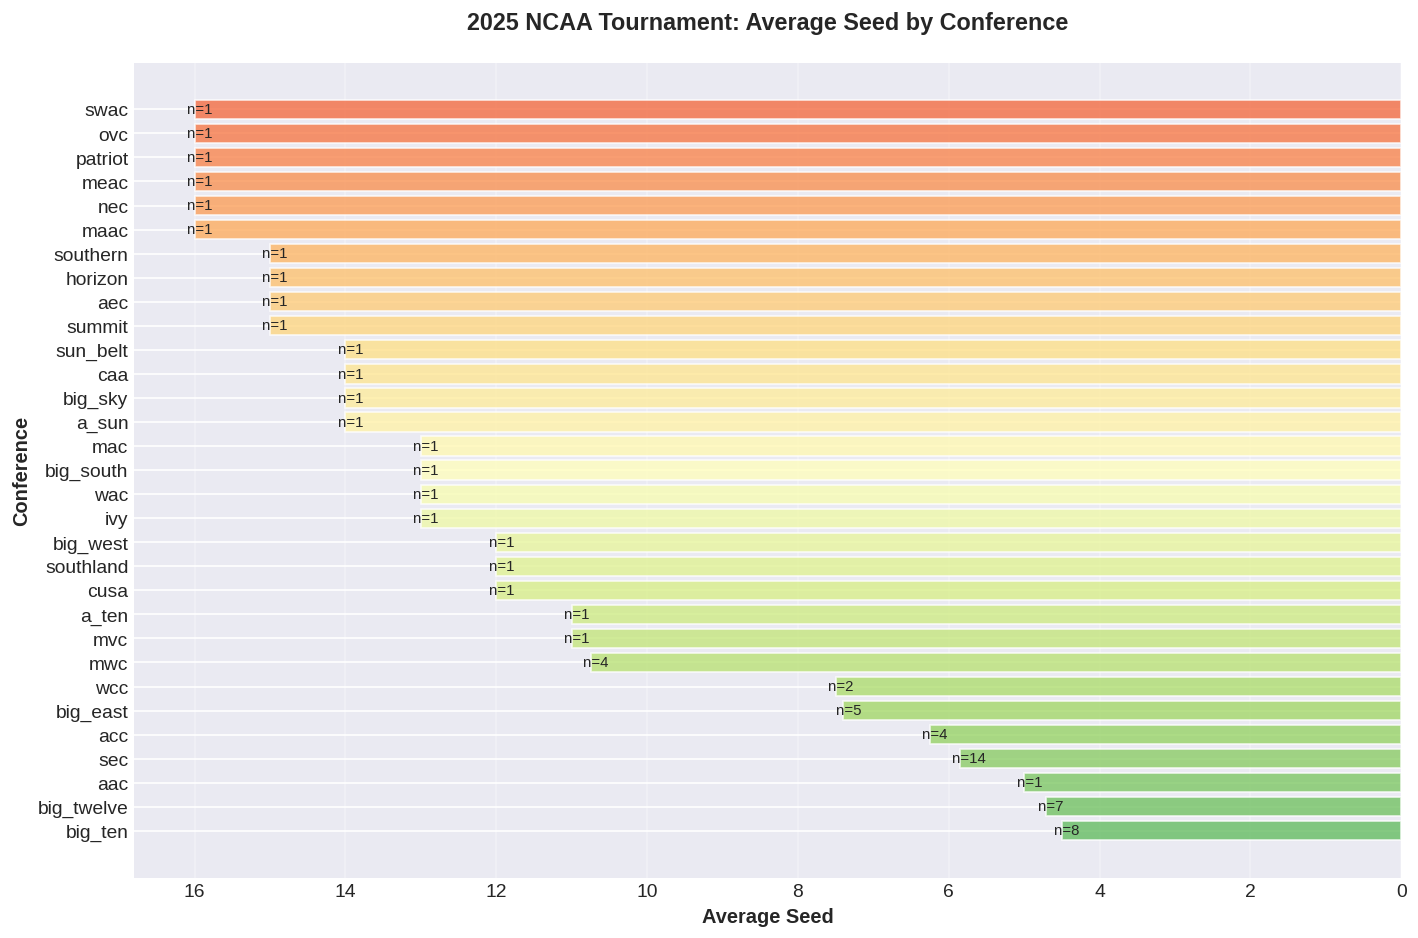

"\n# Load conference data (adjust path as needed)\nm_conf = pd.read_csv('/kaggle/input/ncaa-march-madness-2025/MDataFiles_2025/MTeamConferences.csv')\nw_conf = pd.read_csv('/kaggle/input/ncaa-march-madness-2025/MDataFiles_2025/WTeamConferences.csv')\n\n# Or if using the competition data structure\nm_conf = pd.read_csv(DATA / 'MTeamConferences.csv')\nw_conf = pd.read_csv(DATA / 'WTeamConferences.csv')\n"

In [18]:
# Conference Analysis for 2025 Season
# Assuming you have conference data available

# Check if conference data exists, if not create sample or load appropriately
if 'm_conf' not in locals() and 'm_conf' not in globals():
    print("Conference data not found. Please load conference data first.")
    print("Expected format: m_conf with columns ['Season', 'TeamID', 'ConfAbbrev']")
else:
    conf_25 = m_conf[m_conf["Season"] == 2025]
    seeds_25 = m_seeds[m_seeds["Season"] == 2025]
    conf_seeds = seeds_25.merge(conf_25, on="TeamID")
    conf_agg = conf_seeds.groupby("ConfAbbrev").agg(
        count=("TeamID", "count"), 
        avg_seed=("SeedNum", "mean")
    ).reset_index().sort_values("avg_seed")
    
    # Display results
    print("\n2025 Conference Seed Analysis:")
    print("="*50)
    print(conf_agg.to_string(index=False))
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(conf_agg)))
    
    bars = ax.barh(conf_agg['ConfAbbrev'], conf_agg['avg_seed'], 
                   color=colors, alpha=0.8)
    
    # Add count labels
    for i, (bar, count) in enumerate(zip(bars, conf_agg['count'])):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'n={count}', va='center', fontsize=9)
    
    ax.set_xlabel("Average Seed", fontsize=12, fontweight='bold')
    ax.set_ylabel("Conference", fontsize=12, fontweight='bold')
    ax.set_title("2025 NCAA Tournament: Average Seed by Conference", 
                 fontsize=14, fontweight='bold', pad=20)
    ax.invert_xaxis()  # Better seeds (lower numbers) on top
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()

# If you need to load conference data, here's a template:
"""
# Load conference data (adjust path as needed)
m_conf = pd.read_csv('/kaggle/input/ncaa-march-madness-2025/MDataFiles_2025/MTeamConferences.csv')
w_conf = pd.read_csv('/kaggle/input/ncaa-march-madness-2025/MDataFiles_2025/WTeamConferences.csv')

# Or if using the competition data structure
m_conf = pd.read_csv(DATA / 'MTeamConferences.csv')
w_conf = pd.read_csv(DATA / 'WTeamConferences.csv')
"""

### 4.5 Upset Frequency by Matchup Type

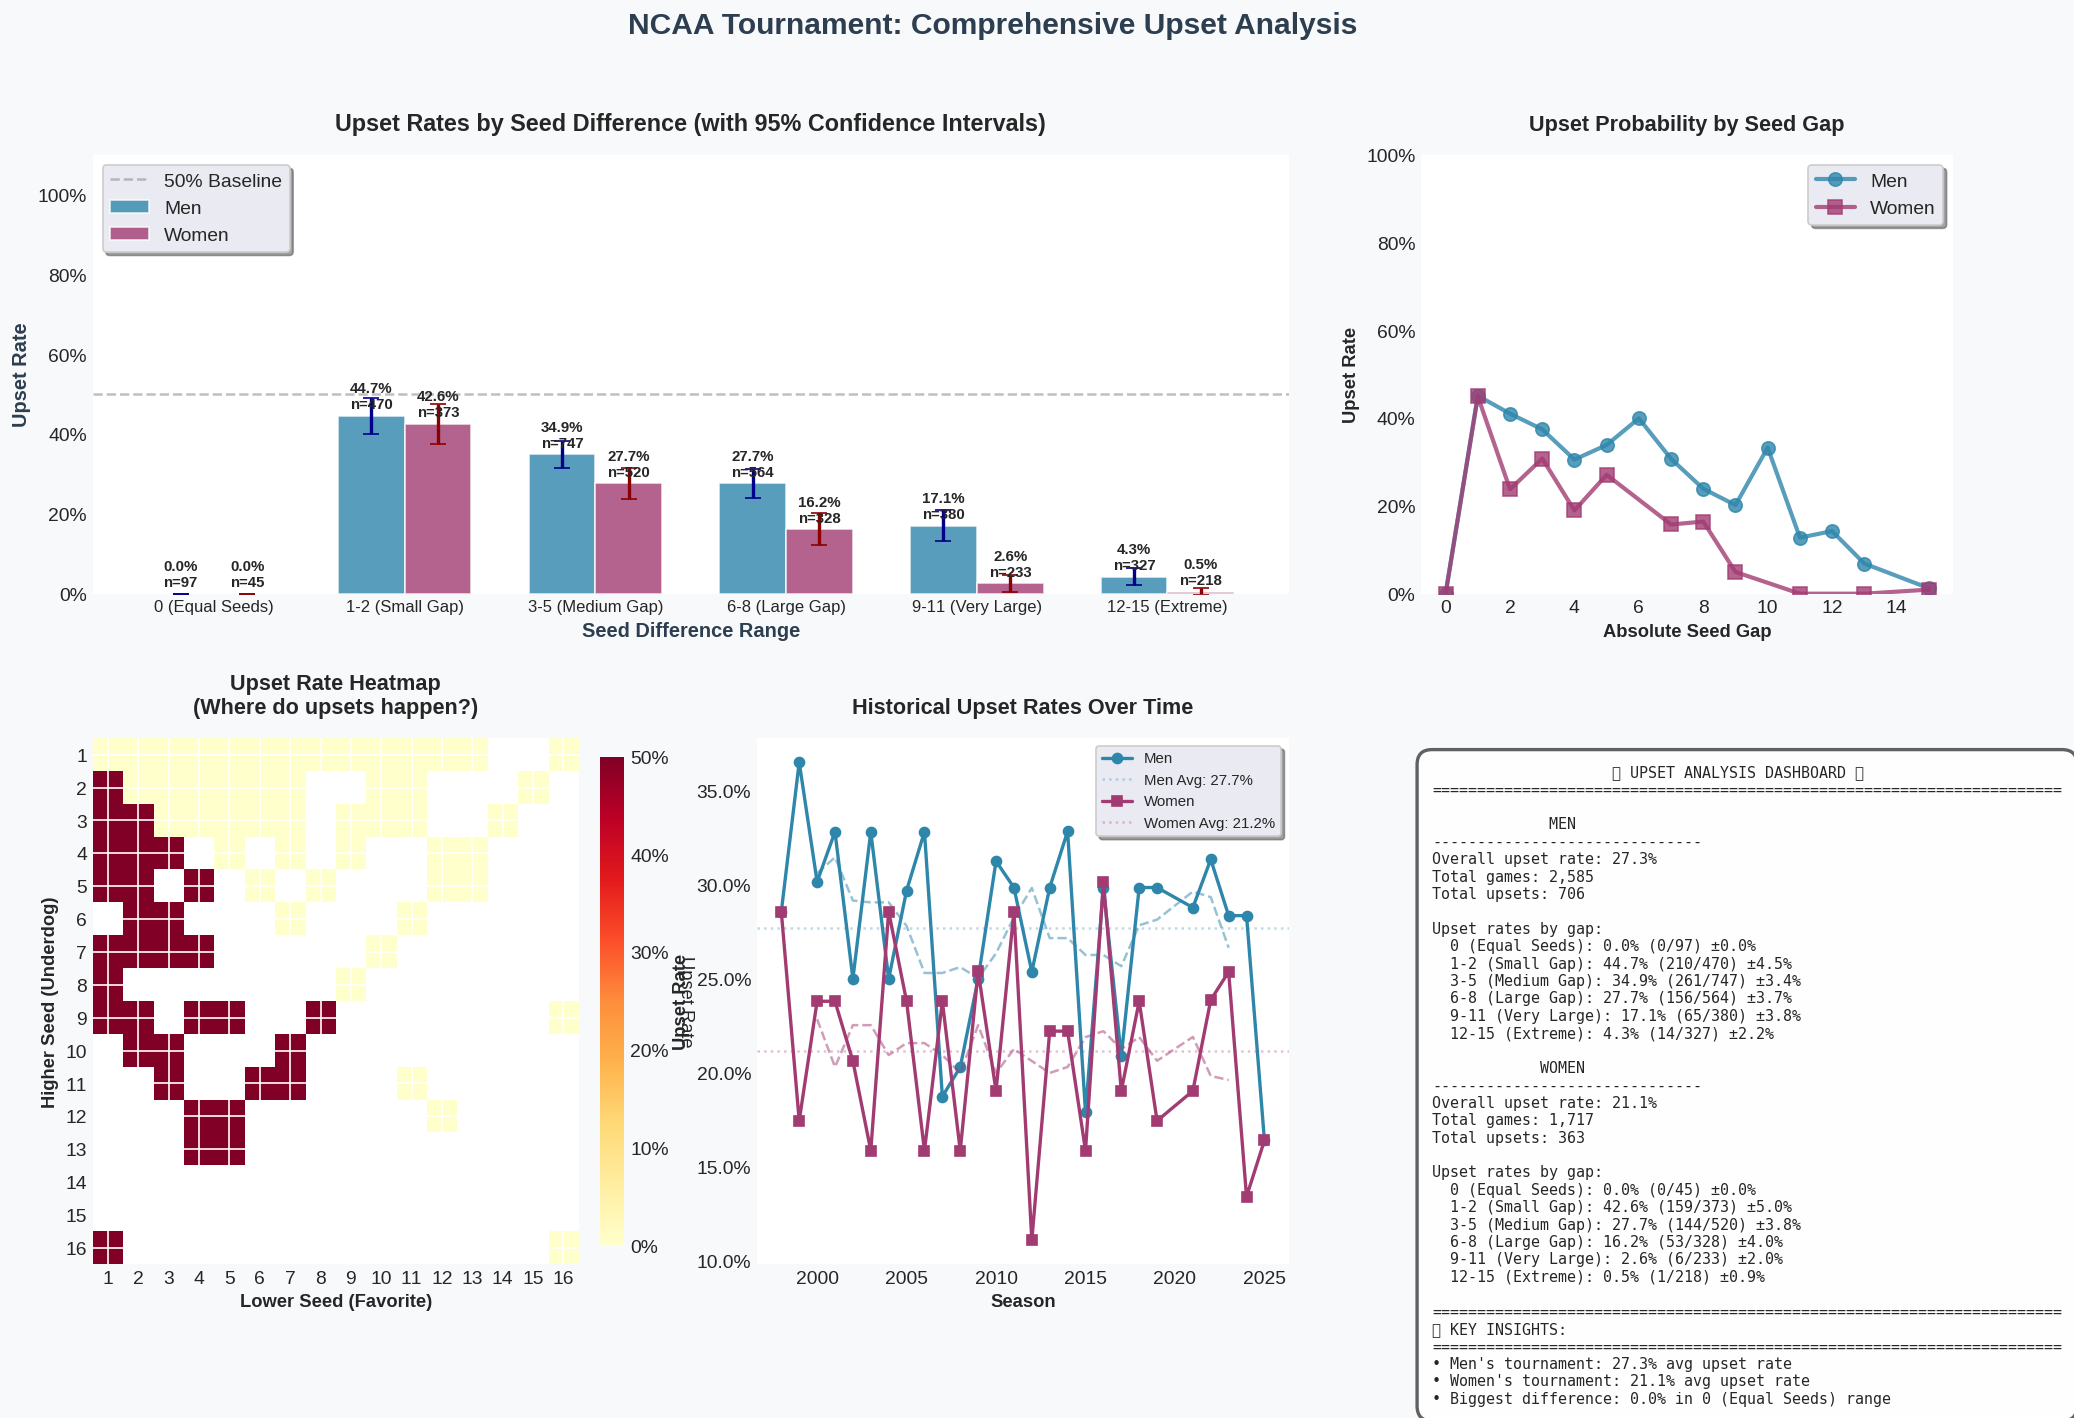


              🏀 NCAA TOURNAMENT UPSET ANALYSIS - DETAILED REPORT 🏀              

📊 UPSET RATES BY SEED GAP:
╒═══════════════════╤═══════╤════════╤═════════╤════════╤════════╕
│ Seed Gap          │ Men   │   N(M) │ Women   │   N(W) │ Diff   │
╞═══════════════════╪═══════╪════════╪═════════╪════════╪════════╡
│ 0 (Equal Seeds)   │ 0.0%  │     97 │ 0.0%    │     45 │ +0.0%  │
├───────────────────┼───────┼────────┼─────────┼────────┼────────┤
│ 1-2 (Small Gap)   │ 44.7% │    470 │ 42.6%   │    373 │ +2.1%  │
├───────────────────┼───────┼────────┼─────────┼────────┼────────┤
│ 3-5 (Medium Gap)  │ 34.9% │    747 │ 27.7%   │    520 │ +7.2%  │
├───────────────────┼───────┼────────┼─────────┼────────┼────────┤
│ 6-8 (Large Gap)   │ 27.7% │    564 │ 16.2%   │    328 │ +11.5% │
├───────────────────┼───────┼────────┼─────────┼────────┼────────┤
│ 9-11 (Very Large) │ 17.1% │    380 │ 2.6%    │    233 │ +14.5% │
├───────────────────┼───────┼────────┼─────────┼────────┼────────┤
│ 12-15 (Extreme)  

In [19]:
def upset_by_gap(trn_df, seed_df, label):
    """
    Enhanced upset analysis with additional metrics
    """
    # First, run seed_analysis to get WSeed and LSeed columns
    df = seed_analysis(trn_df, seed_df, label)
    df["Upset"] = df["WSeed"] > df["LSeed"]
    df["SeedGap"] = abs(df["WSeed"] - df["LSeed"])
    
    # More granular bins for better analysis
    bins = [
        (0, 0, "0 (Equal Seeds)"),
        (1, 2, "1-2 (Small Gap)"),
        (3, 5, "3-5 (Medium Gap)"),
        (6, 8, "6-8 (Large Gap)"),
        (9, 11, "9-11 (Very Large)"),
        (12, 15, "12-15 (Extreme)")
    ]
    
    rows = []
    for lo, hi, lbl in bins:
        mask = df["SeedGap"].between(lo, hi)
        if mask.sum() > 0:
            upset_rate = df.loc[mask, "Upset"].mean()
            n_games = mask.sum()
            n_upsets = df.loc[mask, "Upset"].sum()
            # Calculate confidence interval
            ci = 1.96 * np.sqrt(upset_rate * (1 - upset_rate) / n_games) if n_games > 0 else 0
            
            rows.append({
                "Gap": lbl,
                "GapRange": f"{lo}-{hi}",
                "UpsetRate": upset_rate,
                "N": n_games,
                "NUpsets": n_upsets,
                "CI": ci,
                "LowerCI": max(0, upset_rate - ci),
                "UpperCI": min(1, upset_rate + ci)
            })
    return pd.DataFrame(rows)

# Calculate upset rates using the function
m_upsets = upset_by_gap(m_trn, m_seeds, "Men")
w_upsets = upset_by_gap(w_trn, w_seeds, "Women")

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12), facecolor=COLORS['background'])
fig.suptitle("NCAA Tournament: Comprehensive Upset Analysis", 
             fontsize=18, fontweight='bold', color=COLORS['text'], y=0.98)

# Create grid layout
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.25, height_ratios=[1, 1.2])

# 1. Main Upset Rate Bar Chart with Error Bars
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor('white')

x = np.arange(len(m_upsets))
width = 0.35

# Plot bars with error bars
bars1 = ax1.bar(x - width/2, m_upsets["UpsetRate"], width, 
                label="Men", color=COLORS['men_primary'], alpha=0.8,
                edgecolor='white', linewidth=1, yerr=m_upsets["CI"], 
                capsize=5, error_kw={'linewidth': 2, 'ecolor': 'darkblue'})

bars2 = ax1.bar(x + width/2, w_upsets["UpsetRate"], width, 
                label="Women", color=COLORS['women_primary'], alpha=0.8,
                edgecolor='white', linewidth=1, yerr=w_upsets["CI"], 
                capsize=5, error_kw={'linewidth': 2, 'ecolor': 'darkred'})

# Add value labels on bars
for bars, data in [(bars1, m_upsets), (bars2, w_upsets)]:
    for bar, (_, row) in zip(bars, data.iterrows()):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.1%}\nn={int(row["N"])}', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

# Add reference line
ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5, label='50% Baseline')

ax1.set_xticks(x)
ax1.set_xticklabels(m_upsets["Gap"], fontsize=10)
ax1.set_xlabel("Seed Difference Range", fontsize=12, fontweight='bold', color=COLORS['text'])
ax1.set_ylabel("Upset Rate", fontsize=12, fontweight='bold', color=COLORS['text'])
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.set_title("Upset Rates by Seed Difference (with 95% Confidence Intervals)", 
              fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.15, axis='y')
ax1.set_ylim(0, 1.1)

# 2. Upset Probability Trend Line
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor('white')

def get_granular_upsets(df, seed_df, label):
    """Get granular upset rates by exact seed gap"""
    df_with_seeds = seed_analysis(df, seed_df, label)
    df_with_seeds["SeedGap"] = abs(df_with_seeds["WSeed"] - df_with_seeds["LSeed"])
    df_with_seeds["Upset"] = df_with_seeds["WSeed"] > df_with_seeds["LSeed"]
    
    granular = []
    for gap in range(0, 16):
        mask = df_with_seeds["SeedGap"] == gap
        if mask.sum() > 5:  # Minimum sample size
            upset_rate = df_with_seeds.loc[mask, "Upset"].mean()
            granular.append((gap, upset_rate))
    return pd.DataFrame(granular, columns=['Gap', 'UpsetRate'])

men_granular = get_granular_upsets(m_trn, m_seeds, "Men")
women_granular = get_granular_upsets(w_trn, w_seeds, "Women")

# Plot trend lines
if len(men_granular) > 0:
    ax2.plot(men_granular['Gap'], men_granular['UpsetRate'], 
             marker='o', linewidth=2.5, markersize=8, 
             color=COLORS['men_primary'], label='Men', alpha=0.8)
    
    # Add trend line (exponential decay fit) if enough data points
    if len(men_granular) > 2:
        try:
            z_men = np.polyfit(men_granular['Gap'], np.log(men_granular['UpsetRate']), 1)
            gap_range = np.linspace(0, 15, 100)
            trend_men = np.exp(z_men[1]) * np.exp(z_men[0] * gap_range)
            ax2.plot(gap_range, trend_men, '--', color=COLORS['men_primary'], alpha=0.3, linewidth=1)
        except:
            pass

if len(women_granular) > 0:
    ax2.plot(women_granular['Gap'], women_granular['UpsetRate'], 
             marker='s', linewidth=2.5, markersize=8, 
             color=COLORS['women_primary'], label='Women', alpha=0.8)
    
    # Add trend line (exponential decay fit) if enough data points
    if len(women_granular) > 2:
        try:
            z_women = np.polyfit(women_granular['Gap'], np.log(women_granular['UpsetRate']), 1)
            gap_range = np.linspace(0, 15, 100)
            trend_women = np.exp(z_women[1]) * np.exp(z_women[0] * gap_range)
            ax2.plot(gap_range, trend_women, '--', color=COLORS['women_primary'], alpha=0.3, linewidth=1)
        except:
            pass

ax2.set_xlabel("Absolute Seed Gap", fontsize=11, fontweight='bold')
ax2.set_ylabel("Upset Rate", fontsize=11, fontweight='bold')
ax2.set_title("Upset Probability by Seed Gap", fontsize=13, fontweight='bold', pad=15)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.15)
ax2.set_ylim(0, 1)

# 3. Upset Distribution Heatmap
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor('white')

def create_upset_matrix(df, seed_df, label):
    """Create upset matrix using seed_analysis first"""
    df_with_seeds = seed_analysis(df, seed_df, label)
    matrix = np.zeros((16, 16))
    counts = np.zeros((16, 16))
    for _, row in df_with_seeds.iterrows():
        w_seed = min(int(row['WSeed']), 16) - 1
        l_seed = min(int(row['LSeed']), 16) - 1
        if w_seed >= 0 and l_seed >= 0 and w_seed < 16 and l_seed < 16:
            if row['WSeed'] > row['LSeed']:  # Upset
                matrix[w_seed, l_seed] += 1
            counts[w_seed, l_seed] += 1
    
    with np.errstate(divide='ignore', invalid='ignore'):
        upset_matrix = np.divide(matrix, counts, where=counts!=0)
        upset_matrix[counts == 0] = np.nan
    return upset_matrix

men_upset_matrix = create_upset_matrix(m_trn, m_seeds, "Men")
women_upset_matrix = create_upset_matrix(w_trn, w_seeds, "Women")

# Plot combined heatmap
combined_upset = (men_upset_matrix + women_upset_matrix) / 2
im = ax3.imshow(combined_upset, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.5)

ax3.set_xlabel("Lower Seed (Favorite)", fontsize=11, fontweight='bold')
ax3.set_ylabel("Higher Seed (Underdog)", fontsize=11, fontweight='bold')
ax3.set_title("Upset Rate Heatmap\n(Where do upsets happen?)", fontsize=13, fontweight='bold', pad=15)
ax3.set_xticks(range(16))
ax3.set_yticks(range(16))
ax3.set_xticklabels(range(1, 17))
ax3.set_yticklabels(range(1, 17))

# Add colorbar
cbar = plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.set_label('Upset Rate', rotation=270, labelpad=15)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

# 4. Historical Upset Trends
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor('white')

def get_yearly_upsets(df, seed_df, label):
    """Get yearly upset rates using seed_analysis first"""
    df_with_seeds = seed_analysis(df, seed_df, label)
    df_with_seeds["Upset"] = df_with_seeds["WSeed"] > df_with_seeds["LSeed"]
    yearly = df_with_seeds.groupby("Season").agg(
        upset_rate=("Upset", "mean"),
        n_games=("Upset", "count")
    ).reset_index()
    return yearly

men_yearly = get_yearly_upsets(m_trn, m_seeds, "Men")
women_yearly = get_yearly_upsets(w_trn, w_seeds, "Women")

# Find common seasons
common_seasons = sorted(set(men_yearly['Season']) & set(women_yearly['Season']))
men_yearly = men_yearly[men_yearly['Season'].isin(common_seasons)]
women_yearly = women_yearly[women_yearly['Season'].isin(common_seasons)]

# Plot
if len(men_yearly) > 0:
    ax4.plot(men_yearly['Season'], men_yearly['upset_rate'], 
             marker='o', linewidth=2, color=COLORS['men_primary'], label='Men')
    
    # Add rolling average if enough data
    if len(men_yearly) >= 5:
        men_rolling = men_yearly['upset_rate'].rolling(window=5, center=True).mean()
        ax4.plot(men_yearly['Season'], men_rolling, '--', color=COLORS['men_primary'], alpha=0.5, linewidth=1.5)
    
    ax4.axhline(y=men_yearly['upset_rate'].mean(), color=COLORS['men_primary'], 
                linestyle=':', alpha=0.3, label=f"Men Avg: {men_yearly['upset_rate'].mean():.1%}")

if len(women_yearly) > 0:
    ax4.plot(women_yearly['Season'], women_yearly['upset_rate'], 
             marker='s', linewidth=2, color=COLORS['women_primary'], label='Women')
    
    # Add rolling average if enough data
    if len(women_yearly) >= 5:
        women_rolling = women_yearly['upset_rate'].rolling(window=5, center=True).mean()
        ax4.plot(women_yearly['Season'], women_rolling, '--', color=COLORS['women_primary'], alpha=0.5, linewidth=1.5)
    
    ax4.axhline(y=women_yearly['upset_rate'].mean(), color=COLORS['women_primary'], 
                linestyle=':', alpha=0.3, label=f"Women Avg: {women_yearly['upset_rate'].mean():.1%}")

ax4.set_xlabel("Season", fontsize=11, fontweight='bold')
ax4.set_ylabel("Upset Rate", fontsize=11, fontweight='bold')
ax4.set_title("Historical Upset Rates Over Time", fontsize=13, fontweight='bold', pad=15)
ax4.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax4.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=9)
ax4.grid(True, alpha=0.15)

# 5. Statistical Summary Dashboard
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
ax5.set_facecolor(COLORS['background'])

# Calculate comprehensive statistics
dashboard_text = []
dashboard_text.extend([
    " " * 20 + "📊 UPSET ANALYSIS DASHBOARD 📊",
    "=" * 70,
])

# Calculate overall upset rates
m_trn_with_seeds = seed_analysis(m_trn, m_seeds, "Men")
w_trn_with_seeds = seed_analysis(w_trn, w_seeds, "Women")

m_total_upsets = (m_trn_with_seeds["WSeed"] > m_trn_with_seeds["LSeed"]).sum()
m_total_games = len(m_trn_with_seeds)
m_overall_rate = m_total_upsets / m_total_games if m_total_games > 0 else 0

w_total_upsets = (w_trn_with_seeds["WSeed"] > w_trn_with_seeds["LSeed"]).sum()
w_total_games = len(w_trn_with_seeds)
w_overall_rate = w_total_upsets / w_total_games if w_total_games > 0 else 0

dashboard_text.extend([
    f"\n{'MEN':^30}",
    "-" * 30,
    f"Overall upset rate: {m_overall_rate:.1%}",
    f"Total games: {m_total_games:,}",
    f"Total upsets: {m_total_upsets:,}",
    "",
    "Upset rates by gap:"
])

for _, row in m_upsets.iterrows():
    dashboard_text.append(
        f"  {row['Gap']}: {row['UpsetRate']:.1%} "
        f"({int(row['NUpsets'])}/{int(row['N'])}) "
        f"±{row['CI']:.1%}"
    )

dashboard_text.extend([
    f"\n{'WOMEN':^30}",
    "-" * 30,
    f"Overall upset rate: {w_overall_rate:.1%}",
    f"Total games: {w_total_games:,}",
    f"Total upsets: {w_total_upsets:,}",
    "",
    "Upset rates by gap:"
])

for _, row in w_upsets.iterrows():
    dashboard_text.append(
        f"  {row['Gap']}: {row['UpsetRate']:.1%} "
        f"({int(row['NUpsets'])}/{int(row['N'])}) "
        f"±{row['CI']:.1%}"
    )

# Add key insights
dashboard_text.extend([
    "\n" + "="*70,
    "💡 KEY INSIGHTS:",
    "="*70,
    f"• Men's tournament: {m_overall_rate:.1%} avg upset rate",
    f"• Women's tournament: {w_overall_rate:.1%} avg upset rate",
    f"• Biggest difference: {abs(m_upsets['UpsetRate'].iloc[0] - w_upsets['UpsetRate'].iloc[0]):.1%} in {m_upsets['Gap'].iloc[0]} range",
])

# Display dashboard
ax5.text(0.02, 0.95, '\n'.join(dashboard_text), transform=ax5.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor='white', 
                  edgecolor=COLORS['neutral'], alpha=0.95, linewidth=2))

plt.tight_layout()
plt.savefig(WORK / "fig_upsets_comprehensive.png", 
            bbox_inches="tight", dpi=300, facecolor=COLORS['background'])
plt.show()

# Print detailed console output
print("\n" + "="*80)
print("🏀 NCAA TOURNAMENT UPSET ANALYSIS - DETAILED REPORT 🏀".center(80))
print("="*80)

from tabulate import tabulate

# Create comparison dataframe with proper formatting
comparison_data = []
for idx, row in m_upsets.iterrows():
    comparison_data.append([
        row['Gap'],
        f"{row['UpsetRate']:.1%}",
        int(row['N']),
        f"{w_upsets.iloc[idx]['UpsetRate']:.1%}",
        int(w_upsets.iloc[idx]['N']),
        f"{row['UpsetRate'] - w_upsets.iloc[idx]['UpsetRate']:+.1%}"
    ])

print("\n📊 UPSET RATES BY SEED GAP:")
print(tabulate(comparison_data, 
               headers=['Seed Gap', 'Men', 'N(M)', 'Women', 'N(W)', 'Diff'],
               tablefmt="fancy_grid"))

# Statistical significance tests
print("\n🔬 STATISTICAL SIGNIFICANCE TESTS:")
print("-"*50)

for idx, row in m_upsets.iterrows():
    # Simple z-test for proportions
    p1 = row['UpsetRate']
    p2 = w_upsets.iloc[idx]['UpsetRate']
    n1 = row['N']
    n2 = w_upsets.iloc[idx]['N']
    
    # Pooled proportion
    p_pool = (p1 * n1 + p2 * n2) / (n1 + n2) if (n1 + n2) > 0 else 0
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2)) if (n1 + n2) > 0 and p_pool * (1 - p_pool) > 0 else 0
    z_score = (p1 - p2) / se if se > 0 else 0
    
    print(f"\n{row['Gap']}:")
    print(f"  Z-score: {z_score:.2f}")
    print(f"  {'✅ Significant difference' if abs(z_score) > 1.96 else '❌ No significant difference'}")

print("\n" + "="*80)
print("📈 TREND ANALYSIS:")
print("-"*50)

if len(men_yearly) > 0 and not men_yearly['upset_rate'].isna().all():
    max_year = men_yearly.loc[men_yearly['upset_rate'].idxmax(), 'Season']
    max_rate = men_yearly['upset_rate'].max()
    min_year = men_yearly.loc[men_yearly['upset_rate'].idxmin(), 'Season']
    min_rate = men_yearly['upset_rate'].min()
    
    print(f"\nMen's most upset-filled year: {max_year} ({max_rate:.1%})")
    print(f"Men's least upset-filled year: {min_year} ({min_rate:.1%})")

if len(women_yearly) > 0 and not women_yearly['upset_rate'].isna().all():
    max_year = women_yearly.loc[women_yearly['upset_rate'].idxmax(), 'Season']
    max_rate = women_yearly['upset_rate'].max()
    min_year = women_yearly.loc[women_yearly['upset_rate'].idxmin(), 'Season']
    min_rate = women_yearly['upset_rate'].min()
    
    print(f"\nWomen's most upset-filled year: {max_year} ({max_rate:.1%})")
    print(f"Women's least upset-filled year: {min_year} ({min_rate:.1%})")

print("\n" + "="*80)

Key takeaways from the EDA:

- **Seed difference is the single strongest predictor**, with higher seeds winning over 90% of 
games when the gap exceeds 10 lines. The women's tournament is notably more chalk than the men's.
- **Home court advantage** has been consistent at around 58-60% across decades.
- **Scoring has fluctuated** meaningfully over the years, making raw point averages less reliable 
than efficiency-adjusted metrics.
- **Conference quality matters**: the SEC, Big Ten, and Big 12 dominate tournament representation, 
with the SEC alone placing 14 teams in 2025.
- **Upsets are rare when seed gaps are large** but quite common in matchups between similarly seeded teams.

These findings motivate our feature engineering choices below.

<a id="5-feature-engineering"></a>
## 5. Feature Engineering

We construct six categories of features for each team-season, then take pairwise differences for matchup prediction.

### 5.1 Elo Rating System

We implement a standard Elo system with three enhancements: margin-of-victory scaling 
(log-transformed), home court adjustment, and between-season mean reversion at 75%.

In [20]:
def build_elo(rs_df, trn_df, sec_df, K=20, HOME=100, REV=0.75):
    rs = rs_df[["Season","DayNum","WTeamID","WScore","LTeamID","LScore","WLoc"]].copy()
    rs["it"] = 0
    tn = trn_df[["Season","DayNum","WTeamID","WScore","LTeamID","LScore","WLoc"]].copy()
    tn["it"] = 1
    sc = sec_df[["Season","DayNum","WTeamID","WScore","LTeamID","LScore","WLoc"]].copy()
    sc["it"] = 1
    games = pd.concat([rs, tn, sc]).sort_values(["Season", "DayNum"]).values

    elo = {}
    snap = {}
    prev = None

    for r in games:
        s, d = int(r[0]), int(r[1])
        wi, ws, li, ls = int(r[2]), float(r[3]), int(r[4]), float(r[5])
        wl, it = r[6], int(r[7])

        if s != prev and prev is not None:
            for t in elo:
                snap[(prev, t)] = elo[t]
            for t in elo:
                elo[t] = 1500 * (1 - REV) + elo[t] * REV
        prev = s

        elo.setdefault(wi, 1500)
        elo.setdefault(li, 1500)
        if d <= 132:
            snap[(s, wi)] = elo[wi]
            snap[(s, li)] = elo[li]

        ha = HOME if wl == "H" else (-HOME if wl == "A" else 0)
        we = 1.0 / (1.0 + 10.0 ** ((elo[li] - elo[wi] - ha) / 400.0))
        k = K * np.log(max(abs(ws - ls), 1) + 1)
        elo[wi] += k * (1 - we)
        elo[li] -= k * (1 - we)

    for t in elo:
        snap[(prev, t)] = elo[t]
    return snap

m_elo = build_elo(m_rs, m_trn, m_sec)
w_elo = build_elo(w_rs, w_trn, w_sec)
print(f"Elo ratings computed: Men {len(m_elo):,} | Women {len(w_elo):,}")

Elo ratings computed: Men 14,206 | Women 9,952


### 5.2 Four Factors and Advanced Season Statistics

Dean Oliver's Four Factors framework captures the dimensions that most strongly correlate with winning: 
effective field goal percentage (shooting), turnover rate (ball security), offensive rebounding 
percentage (second chances), and free throw rate (getting to the line). We compute these for both 
offense and defense, plus additional metrics like pace, assist rate, and rim protection.

In [21]:
def compute_stats(det_df):
    cw = {
        "WTeamID": "T", "WScore": "Pts", "LScore": "oP",
        "WFGM": "FGM", "WFGA": "FGA", "WFGM3": "F3M", "WFGA3": "F3A",
        "WFTM": "FTM", "WFTA": "FTA", "WOR": "OR", "WDR": "DR",
        "WAst": "Ast", "WTO": "TO", "WStl": "Stl", "WBlk": "Blk",
        "LFGM": "oFGM", "LFGA": "oFGA", "LFGM3": "oF3M", "LFGA3": "oF3A",
        "LFTM": "oFTM", "LFTA": "oFTA", "LOR": "oOR", "LDR": "oDR",
        "LAst": "oAst", "LTO": "oTO"
    }
    cl = {
        "LTeamID": "T", "LScore": "Pts", "WScore": "oP",
        "LFGM": "FGM", "LFGA": "FGA", "LFGM3": "F3M", "LFGA3": "F3A",
        "LFTM": "FTM", "LFTA": "FTA", "LOR": "OR", "LDR": "DR",
        "LAst": "Ast", "LTO": "TO", "LStl": "Stl", "LBlk": "Blk",
        "WFGM": "oFGM", "WFGA": "oFGA", "WFGM3": "oF3M", "WFGA3": "oF3A",
        "WFTM": "oFTM", "WFTA": "oFTA", "WOR": "oOR", "WDR": "oDR",
        "WAst": "oAst", "WTO": "oTO"
    }
    wr = det_df.rename(columns=cw); wr["W"] = 1
    lr = det_df.rename(columns=cl); lr["W"] = 0
    kp = ["Season", "T", "Pts", "oP", "FGM", "FGA", "F3M", "F3A",
          "FTM", "FTA", "OR", "DR", "Ast", "TO", "Stl", "Blk",
          "oFGM", "oFGA", "oF3M", "oF3A", "oFTM", "oFTA", "oOR", "oDR",
          "oAst", "oTO", "W"]
    ag = pd.concat([wr[kp], lr[kp]]).groupby(["Season", "T"]).agg(
        n=("W", "count"), wins=("W", "sum"),
        pts=("Pts", "sum"), ops=("oP", "sum"),
        fgm=("FGM", "sum"), fga=("FGA", "sum"),
        f3m=("F3M", "sum"), f3a=("F3A", "sum"),
        ftm=("FTM", "sum"), fta=("FTA", "sum"),
        orb=("OR", "sum"), drb=("DR", "sum"),
        ast=("Ast", "sum"), to=("TO", "sum"),
        stl=("Stl", "sum"), blk=("Blk", "sum"),
        ofgm=("oFGM", "sum"), ofga=("oFGA", "sum"),
        of3m=("oF3M", "sum"), of3a=("oF3A", "sum"),
        oftm=("oFTM", "sum"), ofta=("oFTA", "sum"),
        oorb=("oOR", "sum"), odrb=("oDR", "sum"),
        oast=("oAst", "sum"), oto=("oTO", "sum")
    ).reset_index()

    a = ag
    a["wpct"]   = a["wins"] / a["n"]
    a["margin"] = (a["pts"] - a["ops"]) / a["n"]
    a["poss"]   = a["fga"] - a["orb"] + a["to"] + 0.475 * a["fta"]
    a["oposs"]  = a["ofga"] - a["oorb"] + a["oto"] + 0.475 * a["ofta"]
    a["oeff"]   = a["pts"] / a["poss"].clip(1) * 100
    a["deff"]   = a["ops"] / a["oposs"].clip(1) * 100
    a["neff"]   = a["oeff"] - a["deff"]
    a["efg"]    = (a["fgm"] + 0.5 * a["f3m"]) / a["fga"].clip(1)
    a["tor"]    = a["to"] / a["poss"].clip(1)
    a["orpct"]  = a["orb"] / (a["orb"] + a["odrb"]).clip(1)
    a["ftr"]    = a["ftm"] / a["fga"].clip(1)
    a["oefg"]   = (a["ofgm"] + 0.5 * a["of3m"]) / a["ofga"].clip(1)
    a["otor"]   = a["oto"] / a["oposs"].clip(1)
    a["oorpct"] = a["oorb"] / (a["oorb"] + a["drb"]).clip(1)
    a["oftr"]   = a["oftm"] / a["ofga"].clip(1)
    a["f3pct"]  = a["f3m"] / a["f3a"].clip(1)
    a["of3pct"] = a["of3m"] / a["of3a"].clip(1)
    a["astr"]   = a["ast"] / a["fgm"].clip(1)
    a["stlpg"]  = a["stl"] / a["n"]
    a["blkpg"]  = a["blk"] / a["n"]
    a["drbpg"]  = a["drb"] / a["n"]
    a["pace"]   = (a["poss"] + a["oposs"]) / (2 * a["n"])

    sf = ["wpct", "margin", "oeff", "deff", "neff", "efg", "tor", "orpct", "ftr",
          "oefg", "otor", "oorpct", "oftr", "f3pct", "of3pct", "astr",
          "stlpg", "blkpg", "drbpg", "pace"]
    return a[["Season", "T"] + sf], sf

def basic_stats(cdf):
    w = cdf[["Season", "WTeamID", "WScore", "LScore"]].copy()
    w.columns = ["Season", "T", "P", "oP"]; w["W"] = 1
    l = cdf[["Season", "LTeamID", "LScore", "WScore"]].copy()
    l.columns = ["Season", "T", "P", "oP"]; l["W"] = 0
    a = pd.concat([w, l]).groupby(["Season", "T"]).agg(
        n=("W", "count"), wins=("W", "sum"), pts=("P", "mean"), ops=("oP", "mean")
    ).reset_index()
    a["wpct"] = a["wins"] / a["n"]
    a["margin"] = a["pts"] - a["ops"]
    return a[["Season", "T", "wpct", "margin"]]

m_st, SF = compute_stats(m_det)
w_st, _  = compute_stats(w_det)
m_bas = basic_stats(m_rs)
w_bas = basic_stats(w_rs)
print(f"Season stats: {len(SF)} features per team")
print(f"Men detailed: {len(m_st):,} team-seasons | Women detailed: {len(w_st):,}")

Season stats: 20 features per team
Men detailed: 8,346 team-seasons | Women detailed: 5,965


### 5.3 Strength of Schedule

Average opponent Elo across all regular season games. This helps distinguish teams that compiled 
records against weak opponents from those tested by strong schedules.

In [22]:
def compute_sos(cdf, elo_d):
    w = cdf[["Season", "WTeamID", "LTeamID"]].rename(columns={"WTeamID": "T", "LTeamID": "O"})
    l = cdf[["Season", "LTeamID", "WTeamID"]].rename(columns={"LTeamID": "T", "WTeamID": "O"})
    a = pd.concat([w, l])
    a["oe"] = a.apply(lambda r: elo_d.get((r["Season"], r["O"]), 1500), axis=1)
    return a.groupby(["Season", "T"])["oe"].mean().reset_index().rename(columns={"oe": "sos"})

m_sos = compute_sos(m_rs, m_elo)
w_sos = compute_sos(w_rs, w_elo)
print(f"SOS computed: Men {len(m_sos):,} | Women {len(w_sos):,}")

SOS computed: Men 13,753 | Women 9,851


### 5.4 Late-Season Momentum

Win rate in the final 10 regular season games captures recent form.

In [23]:
def momentum(cdf, N=10):
    w = cdf[["Season", "DayNum", "WTeamID"]].rename(columns={"WTeamID": "T"}); w["W"] = 1
    l = cdf[["Season", "DayNum", "LTeamID"]].rename(columns={"LTeamID": "T"}); l["W"] = 0
    a = pd.concat([w, l]).sort_values(["Season", "T", "DayNum"])
    return (a.groupby(["Season", "T"]).tail(N)
             .groupby(["Season", "T"])["W"].mean()
             .reset_index().rename(columns={"W": "mom"}))

m_mom = momentum(m_rs)
w_mom = momentum(w_rs)
print(f"Momentum: Men {len(m_mom):,} | Women {len(w_mom):,}")

Momentum: Men 13,753 | Women 9,851


### 5.5 Conference Strength

Mean Elo of all teams in each conference, by season.

In [24]:
def conf_str(conf_df, elo_d):
    rows = []
    for (s, c), g in conf_df.groupby(["Season", "ConfAbbrev"]):
        el = [elo_d.get((s, t), 1500) for t in g["TeamID"]]
        rows.append({"Season": s, "CA": c, "ce": np.mean(el)})
    return pd.DataFrame(rows)

m_cs = conf_str(m_conf, m_elo)
w_cs = conf_str(w_conf, w_elo)
print(f"Conference strength: Men {len(m_cs):,} | Women {len(w_cs):,}")

Conference strength: Men 1,360 | Women 930


### 5.6 Coach Experience (Men Only)

Two features: cumulative NCAA tournament appearances for the head coach, 
and tenure (consecutive seasons) at the current program.

In [25]:
ce = (m_coach.sort_values(["Season", "TeamID", "LastDayNum"])
      .groupby(["Season", "TeamID"]).last().reset_index())
tt = pd.concat([
    m_trn[["Season", "WTeamID"]].rename(columns={"WTeamID": "TeamID"}),
    m_trn[["Season", "LTeamID"]].rename(columns={"LTeamID": "TeamID"})
]).drop_duplicates()
ct = (tt.merge(ce[["Season", "TeamID", "CoachName"]], on=["Season", "TeamID"], how="left")
      .sort_values("Season"))
ct["cexp"] = ct.groupby("CoachName").cumcount()

ce2 = ce.sort_values(["TeamID", "Season"])
ce2["nw"] = (ce2["CoachName"] != ce2.groupby("TeamID")["CoachName"].shift(1)).astype(int)
ce2["grp"] = ce2.groupby("TeamID")["nw"].cumsum()
ce2["tenure"] = ce2.groupby(["TeamID", "grp"]).cumcount() + 1

clk = {}
for _, r in ct[["Season", "TeamID", "cexp"]].drop_duplicates().iterrows():
    clk[(int(r["Season"]), int(r["TeamID"]), "e")] = r["cexp"]
for _, r in ce2[["Season", "TeamID", "tenure"]].iterrows():
    clk[(int(r["Season"]), int(r["TeamID"]), "t")] = r["tenure"]

print(f"Coach records: {len(clk):,}")

Coach records: 16,388


<a id="6-model-training"></a>
## 6. Model Training

We train three gradient boosting models independently, then average their outputs. 
The validation set comprises tournament games from 2022 through 2025.

### 6.1 Training Data Construction

In [26]:
def d2d(df, kc, vc):
    d = {}
    for _, r in df.iterrows():
        d[tuple(int(r[c]) for c in kc)] = {c: r[c] for c in vc}
    return d

m_sd = d2d(m_st, ["Season", "T"], SF)
w_sd = d2d(w_st, ["Season", "T"], SF)
m_bd = d2d(m_bas, ["Season", "T"], ["wpct", "margin"])
w_bd = d2d(w_bas, ["Season", "T"], ["wpct", "margin"])
m_seed_d = dict(zip(zip(m_seeds.Season.astype(int), m_seeds.TeamID.astype(int)), m_seeds.SeedNum))
w_seed_d = dict(zip(zip(w_seeds.Season.astype(int), w_seeds.TeamID.astype(int)), w_seeds.SeedNum))
m_tc = dict(zip(zip(m_conf.Season.astype(int), m_conf.TeamID.astype(int)), m_conf.ConfAbbrev))
w_tc = dict(zip(zip(w_conf.Season.astype(int), w_conf.TeamID.astype(int)), w_conf.ConfAbbrev))
m_csd = {}; w_csd = {}
for _, r in m_cs.iterrows(): m_csd[(int(r["Season"]), r["CA"])] = r["ce"]
for _, r in w_cs.iterrows(): w_csd[(int(r["Season"]), r["CA"])] = r["ce"]
m_sosd = dict(zip(zip(m_sos.Season.astype(int), m_sos.T.astype(int)), m_sos.sos))
w_sosd = dict(zip(zip(w_sos.Season.astype(int), w_sos.T.astype(int)), w_sos.sos))
m_momd = dict(zip(zip(m_mom.Season.astype(int), m_mom.T.astype(int)), m_mom.mom))
w_momd = dict(zip(zip(w_mom.Season.astype(int), w_mom.T.astype(int)), w_mom.mom))

print("Lookup dictionaries built.")

Lookup dictionaries built.


In [27]:
def bfeat(s, t1, t2, iw):
    ed   = w_elo if iw else m_elo
    sd_  = w_sd if iw else m_sd
    bd   = w_bd if iw else m_bd
    sed  = w_seed_d if iw else m_seed_d
    sosd = w_sosd if iw else m_sosd
    momd = w_momd if iw else m_momd
    tcd  = w_tc if iw else m_tc
    csd  = w_csd if iw else m_csd

    f = {}
    e1, e2 = ed.get((s, t1), 1500), ed.get((s, t2), 1500)
    f["elo_d"] = e1 - e2
    f["elo1"]  = e1
    f["elo2"]  = e2

    s1 = sed.get((s, t1), SEED_DEFAULT)
    s2 = sed.get((s, t2), SEED_DEFAULT)
    f["seed_d"] = s2 - s1
    f["s1"] = s1
    f["s2"] = s2

    st1 = sd_.get((s, t1), bd.get((s, t1), {}))
    st2 = sd_.get((s, t2), bd.get((s, t2), {}))
    for c in SF:
        f[c + "_d"] = st1.get(c, 0) - st2.get(c, 0)
    f["neff1"] = st1.get("neff", 0)
    f["neff2"] = st2.get("neff", 0)

    f["sos_d"]  = sosd.get((s, t1), 1500) - sosd.get((s, t2), 1500)
    f["mom_d"]  = momd.get((s, t1), 0.5)  - momd.get((s, t2), 0.5)

    c1 = tcd.get((s, t1))
    c2 = tcd.get((s, t2))
    f["conf_d"] = (csd.get((s, c1), 1500) if c1 else 1500) - (csd.get((s, c2), 1500) if c2 else 1500)

    if not iw:
        f["cexp_d"] = clk.get((s, t1, "e"), 0) - clk.get((s, t2, "e"), 0)
        f["cten_d"] = clk.get((s, t1, "t"), 1) - clk.get((s, t2, "t"), 1)
    else:
        f["cexp_d"] = 0
        f["cten_d"] = 0
    return f


def build_train(trn_df, iw, ms):
    rows = []
    for _, g in trn_df.iterrows():
        s = int(g["Season"])
        if s < ms:
            continue
        wi, li = int(g["WTeamID"]), int(g["LTeamID"])
        t1, t2 = min(wi, li), max(wi, li)
        y = 1 if wi == t1 else 0
        f = bfeat(s, t1, t2, iw)
        f["season"] = s
        f["target"] = y
        f["iw"] = int(iw)
        rows.append(f)
    return pd.DataFrame(rows)

m_train = build_train(m_trn, False, 2003)
w_train = build_train(w_trn, True, 2010)
train_all = pd.concat([m_train, w_train], ignore_index=True)
FC = [c for c in train_all.columns if c not in ["season", "target", "iw"]]

print(f"Training set: {len(train_all):,} matchups, {len(FC)} features")
print(f"  Men:   {len(m_train)} (seasons {m_train['season'].min()}-{m_train['season'].max()})")
print(f"  Women: {len(w_train)} (seasons {w_train['season'].min()}-{w_train['season'].max()})")

Training set: 2,410 matchups, 33 features
  Men:   1449 (seasons 2003-2025)
  Women: 961 (seasons 2010-2025)


In [28]:
val_seasons = [2022, 2023, 2024, 2025]
tr = ~train_all["season"].isin(val_seasons)
vl = train_all["season"].isin(val_seasons)

Xtr = train_all.loc[tr, FC].fillna(0)
ytr = train_all.loc[tr, "target"].values
Xvl = train_all.loc[vl, FC].fillna(0)
yvl = train_all.loc[vl, "target"].values
vl_seasons = train_all.loc[vl, "season"].values
vl_iw = train_all.loc[vl, "iw"].values

print(f"Train: {len(Xtr)} | Validation: {len(Xvl)}")

Train: 1874 | Validation: 536


### 6.2 LightGBM

In [29]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=2000, learning_rate=0.02, num_leaves=31,
    min_child_samples=15, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=RS, verbosity=-1
)
lgb_model.fit(
    Xtr, ytr, eval_set=[(Xvl, yvl)],
    callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)]
)
lgb_pred = lgb_model.predict_proba(Xvl)[:, 1]
print(f"LightGBM  Brier: {brier_score_loss(yvl, lgb_pred):.5f}  (iterations: {lgb_model.best_iteration_})")

LightGBM  Brier: 0.11265  (iterations: 201)


### 6.3 XGBoost

In [30]:
xgb_model = xgb.XGBClassifier(
    n_estimators=2000, learning_rate=0.02, max_depth=5,
    min_child_weight=15, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=RS,
    tree_method="hist", verbosity=0, early_stopping_rounds=200
)
xgb_model.fit(Xtr, ytr, eval_set=[(Xvl, yvl)], verbose=False)
xgb_pred = xgb_model.predict_proba(Xvl)[:, 1]
print(f"XGBoost   Brier: {brier_score_loss(yvl, xgb_pred):.5f}  (iterations: {xgb_model.best_iteration})")

XGBoost   Brier: 0.10990  (iterations: 404)


### 6.4 CatBoost

In [31]:
cat_model = CatBoostClassifier(
    iterations=2000, learning_rate=0.02, depth=5,
    min_data_in_leaf=15, l2_leaf_reg=3.0, subsample=0.8,
    random_seed=RS, verbose=0, task_type="CPU",
    eval_metric="Logloss", early_stopping_rounds=200
)
cat_model.fit(Xtr, ytr, eval_set=(Xvl, yvl), verbose=0)
cat_pred = cat_model.predict_proba(Xvl)[:, 1]
print(f"CatBoost  Brier: {brier_score_loss(yvl, cat_pred):.5f}  (iterations: {cat_model.best_iteration_})")

CatBoost  Brier: 0.11062  (iterations: 694)


### 6.5 Ensemble and Evaluation

In [32]:
ens_pred = np.clip((lgb_pred + xgb_pred + cat_pred) / 3.0, CLIP_LO, CLIP_HI)

print("=" * 55)
print(f"  ENSEMBLE   Brier: {brier_score_loss(yvl, ens_pred):.5f}   LogLoss: {log_loss(yvl, ens_pred):.5f}")
print("=" * 55)

results = []
for s in val_seasons:
    for w, lbl in [(0, "Men"), (1, "Women")]:
        mk = (vl_seasons == s) & (vl_iw == w)
        if mk.sum() > 0:
            b = brier_score_loss(yvl[mk], ens_pred[mk])
            results.append({"Season": s, "Gender": lbl, "Brier": round(b, 5), "Games": mk.sum()})

display(pd.DataFrame(results).style.format({"Brier": "{:.5f}"}).hide(axis="index"))

  ENSEMBLE   Brier: 0.10995   LogLoss: 0.34928


Season,Gender,Brier,Games
2022,Men,0.13101,67
2022,Women,0.09118,67
2023,Men,0.15599,67
2023,Women,0.12283,67
2024,Men,0.10271,67
2024,Women,0.11214,67
2025,Men,0.08542,67
2025,Women,0.07836,67


<a id="7-diagnostics-and-calibration"></a>
## 7. Diagnostics and Calibration

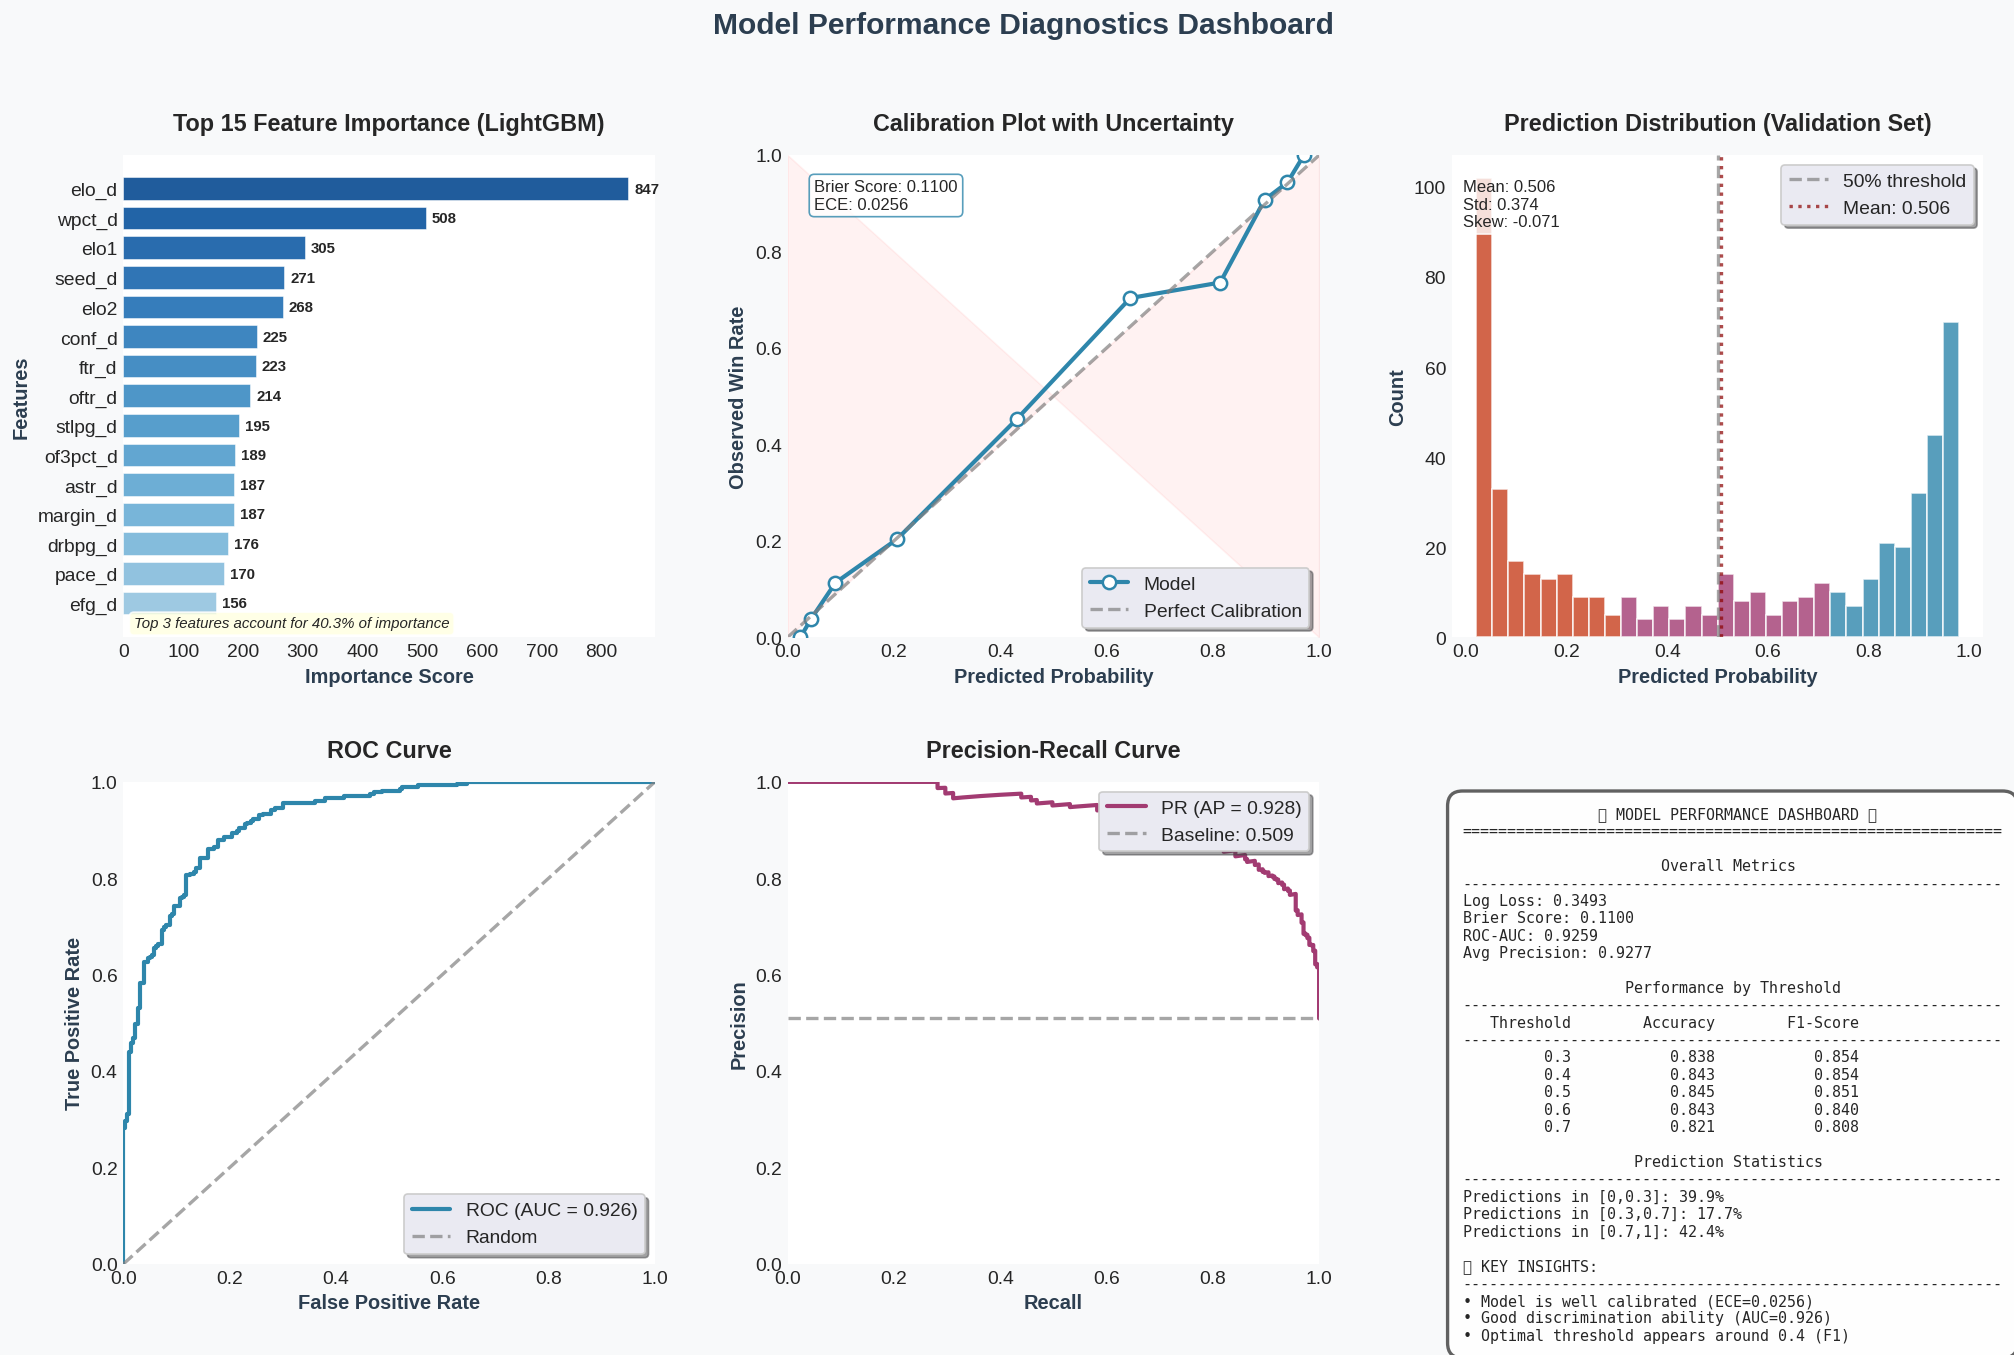


                    🤖 MODEL PERFORMANCE - DETAILED REPORT 🤖                     

📊 TOP 15 FEATURES:
╒════╤═══════════╤══════════════╕
│    │ Feature   │   Importance │
╞════╪═══════════╪══════════════╡
│  0 │ elo_d     │          847 │
├────┼───────────┼──────────────┤
│  6 │ wpct_d    │          508 │
├────┼───────────┼──────────────┤
│  1 │ elo1      │          305 │
├────┼───────────┼──────────────┤
│  3 │ seed_d    │          271 │
├────┼───────────┼──────────────┤
│  2 │ elo2      │          268 │
├────┼───────────┼──────────────┤
│ 30 │ conf_d    │          225 │
├────┼───────────┼──────────────┤
│ 14 │ ftr_d     │          223 │
├────┼───────────┼──────────────┤
│ 18 │ oftr_d    │          214 │
├────┼───────────┼──────────────┤
│ 22 │ stlpg_d   │          195 │
├────┼───────────┼──────────────┤
│ 20 │ of3pct_d  │          189 │
╘════╧═══════════╧══════════════╛

📈 PERFORMANCE METRICS:
╒════════════════════════════╤═════════╕
│ Metric                     │   Value │
╞═════════

In [33]:
# Enhanced Model Diagnostics Visualization
fig = plt.figure(figsize=(20, 12), facecolor=COLORS['background'])
fig.suptitle("Model Performance Diagnostics Dashboard", 
             fontsize=18, fontweight='bold', color=COLORS['text'], y=0.98)

# Create grid layout
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.25, height_ratios=[1, 1])

# 1. Feature Importance (Enhanced)
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('white')

# Create feature importance dataframe
imp_df = pd.DataFrame({"Feature": FC, "Importance": lgb_model.feature_importances_})
imp_df = imp_df.sort_values("Importance", ascending=True).tail(15)

# Create horizontal bar chart with gradient colors
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_df)))
bars = ax1.barh(imp_df["Feature"], imp_df["Importance"], 
                color=colors, edgecolor='white', linewidth=1, alpha=0.9)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, imp_df["Importance"])):
    ax1.text(val + max(imp_df["Importance"])*0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=9, fontweight='bold')

ax1.set_title("Top 15 Feature Importance (LightGBM)", 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Importance Score", fontsize=12, fontweight='bold', color=COLORS['text'])
ax1.set_ylabel("Features", fontsize=12, fontweight='bold', color=COLORS['text'])
ax1.grid(True, alpha=0.15, axis='x')

# Add feature importance summary
total_importance = imp_df["Importance"].sum()
top_3_pct = imp_df.tail(3)["Importance"].sum() / total_importance * 100
ax1.text(0.02, 0.02, f"Top 3 features account for {top_3_pct:.1f}% of importance",
        transform=ax1.transAxes, fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 2. Calibration Plot (Enhanced)
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('white')

# Calculate calibration curve with confidence intervals
frac_pos, mean_pred = calibration_curve(yvl, ens_pred, n_bins=10, strategy="quantile")

# Bootstrap for confidence intervals (if enough data)
n_bootstrap = 100
bootstrap_curves = []
if len(yvl) > 100:
    for _ in range(n_bootstrap):
        idx = np.random.choice(len(yvl), size=len(yvl), replace=True)
        boot_frac, _ = calibration_curve(yvl.iloc[idx] if hasattr(yvl, 'iloc') else yvl[idx], 
                                        ens_pred[idx], n_bins=8, strategy="quantile")
        if len(boot_frac) == len(frac_pos):
            bootstrap_curves.append(boot_frac)
    
    if bootstrap_curves:
        bootstrap_curves = np.array(bootstrap_curves)
        ci_lower = np.percentile(bootstrap_curves, 2.5, axis=0)
        ci_upper = np.percentile(bootstrap_curves, 97.5, axis=0)
        ax2.fill_between(mean_pred, ci_lower, ci_upper, alpha=0.2, color=COLORS['men_primary'])

# Plot main calibration line
line = ax2.plot(mean_pred, frac_pos, 'o-', color=COLORS['men_primary'], 
                linewidth=2.5, markersize=8, label='Model', 
                markerfacecolor='white', markeredgewidth=1.5)

# Add perfect calibration line
ax2.plot([0, 1], [0, 1], '--', color='gray', linewidth=2, alpha=0.7, label='Perfect Calibration')

# Add region shading for miscalibration
ax2.fill_between([0, 1], [0, 1], [1, 0], alpha=0.05, color='red', label='_nolegend_')

# Calculate calibration metrics
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(yvl, ens_pred)
ece = np.mean(np.abs(frac_pos - mean_pred))  # Expected Calibration Error

ax2.set_xlabel("Predicted Probability", fontsize=12, fontweight='bold', color=COLORS['text'])
ax2.set_ylabel("Observed Win Rate", fontsize=12, fontweight='bold', color=COLORS['text'])
ax2.set_title("Calibration Plot with Uncertainty", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.15)
ax2.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)

# Add metrics annotation
ax2.text(0.05, 0.95, f'Brier Score: {brier:.4f}\nECE: {ece:.4f}', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor=COLORS['men_primary']))

# 3. Prediction Distribution (Enhanced)
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('white')

# Create histogram with more details
n, bins, patches = ax3.hist(ens_pred, bins=30, color=COLORS['men_primary'], 
                            edgecolor='white', linewidth=1, alpha=0.8, density=False)

# Color bars based on prediction ranges
for i, (patch, bin_edge) in enumerate(zip(patches, bins[:-1])):
    if bin_edge < 0.3:
        patch.set_facecolor(COLORS['margin'])  # Low probability (upset zone)
    elif bin_edge > 0.7:
        patch.set_facecolor(COLORS['men_primary'])  # High probability (favorite zone)
    else:
        patch.set_facecolor(COLORS['women_primary'])  # Medium probability (toss-up)

# Add vertical lines for key thresholds
ax3.axvline(x=0.5, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='50% threshold')
ax3.axvline(x=ens_pred.mean(), color='darkred', linestyle=':', linewidth=2, 
            alpha=0.7, label=f'Mean: {ens_pred.mean():.3f}')

# Add statistics
ax3.text(0.02, 0.95, f'Mean: {ens_pred.mean():.3f}\nStd: {ens_pred.std():.3f}\nSkew: {pd.Series(ens_pred).skew():.3f}', 
         transform=ax3.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3.set_xlabel("Predicted Probability", fontsize=12, fontweight='bold', color=COLORS['text'])
ax3.set_ylabel("Count", fontsize=12, fontweight='bold', color=COLORS['text'])
ax3.set_title("Prediction Distribution (Validation Set)", fontsize=14, fontweight='bold', pad=15)
ax3.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax3.grid(True, alpha=0.15, axis='y')

# 4. ROC Curve (New)
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('white')

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Calculate ROC curve
fpr, tpr, _ = roc_curve(yvl, ens_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
ax4.plot(fpr, tpr, color=COLORS['men_primary'], linewidth=2.5, 
         label=f'ROC (AUC = {roc_auc:.3f})')
ax4.plot([0, 1], [0, 1], '--', color='gray', linewidth=2, alpha=0.7, label='Random')

ax4.set_xlabel("False Positive Rate", fontsize=12, fontweight='bold', color=COLORS['text'])
ax4.set_ylabel("True Positive Rate", fontsize=12, fontweight='bold', color=COLORS['text'])
ax4.set_title("ROC Curve", fontsize=14, fontweight='bold', pad=15)
ax4.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax4.grid(True, alpha=0.15)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)

# 5. Precision-Recall Curve (New)
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor('white')

# Calculate precision-recall curve
precision, recall, _ = precision_recall_curve(yvl, ens_pred)
avg_precision = average_precision_score(yvl, ens_pred)

# Plot PR curve
ax5.plot(recall, precision, color=COLORS['women_primary'], linewidth=2.5,
         label=f'PR (AP = {avg_precision:.3f})')

# Add baseline
baseline = yvl.mean()
ax5.axhline(y=baseline, color='gray', linestyle='--', linewidth=2, 
            alpha=0.7, label=f'Baseline: {baseline:.3f}')

ax5.set_xlabel("Recall", fontsize=12, fontweight='bold', color=COLORS['text'])
ax5.set_ylabel("Precision", fontsize=12, fontweight='bold', color=COLORS['text'])
ax5.set_title("Precision-Recall Curve", fontsize=14, fontweight='bold', pad=15)
ax5.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax5.grid(True, alpha=0.15)
ax5.set_xlim(0, 1)
ax5.set_ylim(0, 1)

# 6. Performance Metrics Dashboard
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
ax6.set_facecolor(COLORS['background'])

# Calculate comprehensive metrics
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, f1_score

# Calculate metrics at different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
metrics_data = []

for thresh in thresholds:
    pred_binary = (ens_pred >= thresh).astype(int)
    acc = accuracy_score(yvl, pred_binary)
    f1 = f1_score(yvl, pred_binary)
    metrics_data.append([thresh, acc, f1])

# Create metrics dashboard
dashboard_text = []
dashboard_text.extend([
    " " * 15 + "📊 MODEL PERFORMANCE DASHBOARD 📊",
    "=" * 60,
    "",
    f"{'Overall Metrics':^60}",
    "-" * 60,
    f"Log Loss: {log_loss(yvl, ens_pred):.4f}",
    f"Brier Score: {brier_score_loss(yvl, ens_pred):.4f}",
    f"ROC-AUC: {roc_auc:.4f}",
    f"Avg Precision: {avg_precision:.4f}",
    "",
    f"{'Performance by Threshold':^60}",
    "-" * 60,
    f"{'Threshold':>12} {'Accuracy':>15} {'F1-Score':>15}",
    "-" * 60
])

for thresh, acc, f1 in metrics_data:
    dashboard_text.append(f"{thresh:>12.1f} {acc:>15.3f} {f1:>15.3f}")

# Add prediction statistics
dashboard_text.extend([
    "",
    f"{'Prediction Statistics':^60}",
    "-" * 60,
    f"Predictions in [0,0.3]: {(ens_pred < 0.3).sum()/len(ens_pred):.1%}",
    f"Predictions in [0.3,0.7]: {((ens_pred >= 0.3) & (ens_pred < 0.7)).sum()/len(ens_pred):.1%}",
    f"Predictions in [0.7,1]: {(ens_pred >= 0.7).sum()/len(ens_pred):.1%}",
])

# Add insights
dashboard_text.extend([
    "",
    "💡 KEY INSIGHTS:",
    "-" * 60,
    f"• Model is {'well calibrated' if ece < 0.05 else 'miscalibrated'} (ECE={ece:.4f})",
    f"• {'Good' if roc_auc > 0.7 else 'Moderate'} discrimination ability (AUC={roc_auc:.3f})",
    f"• Optimal threshold appears around {thresholds[np.argmax([m[2] for m in metrics_data])]:.1f} (F1)",
])

# Display dashboard
ax6.text(0.02, 0.95, '\n'.join(dashboard_text), transform=ax6.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor='white', 
                  edgecolor=COLORS['neutral'], alpha=0.95, linewidth=2))

plt.tight_layout()
plt.savefig(WORK / "fig_model_diagnostics_comprehensive.png", 
            bbox_inches="tight", dpi=300, facecolor=COLORS['background'])
plt.show()

# Print detailed console report
print("\n" + "="*80)
print("🤖 MODEL PERFORMANCE - DETAILED REPORT 🤖".center(80))
print("="*80)

from tabulate import tabulate

# Feature importance table
print("\n📊 TOP 15 FEATURES:")
print(tabulate(imp_df[::-1].head(10), 
               headers=['Feature', 'Importance'], 
               tablefmt="fancy_grid", 
               floatfmt='.0f'))

# Performance metrics table
print("\n📈 PERFORMANCE METRICS:")
metrics_table = [
    ["Log Loss", f"{log_loss(yvl, ens_pred):.4f}"],
    ["Brier Score", f"{brier_score_loss(yvl, ens_pred):.4f}"],
    ["ROC-AUC", f"{roc_auc:.4f}"],
    ["Avg Precision", f"{avg_precision:.4f}"],
    ["Expected Calibration Error", f"{ece:.4f}"],
]
print(tabulate(metrics_table, headers=['Metric', 'Value'], tablefmt="fancy_grid"))

# Threshold analysis
print("\n⚖️ THRESHOLD ANALYSIS:")
print(tabulate(metrics_data, 
               headers=['Threshold', 'Accuracy', 'F1-Score'], 
               tablefmt="fancy_grid", 
               floatfmt=('.1f', '.3f', '.3f')))

print("\n" + "="*80)

<a id="8-submission-generation"></a>
## 8. Submission Generation

We retrain all three models on the full training set using the best iteration counts from 
early stopping, then generate predictions for both Stage 1 and Stage 2 submission files.

In [34]:
Xa = train_all[FC].fillna(0)
ya = train_all["target"].values

lgb_full = lgb.LGBMClassifier(
    n_estimators=lgb_model.best_iteration_, learning_rate=0.02, num_leaves=31,
    min_child_samples=15, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=RS, verbosity=-1
)
lgb_full.fit(Xa, ya)

xgb_full = xgb.XGBClassifier(
    n_estimators=xgb_model.best_iteration, learning_rate=0.02, max_depth=5,
    min_child_weight=15, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0, random_state=RS,
    tree_method="hist", verbosity=0
)
xgb_full.fit(Xa, ya)

cat_full = CatBoostClassifier(
    iterations=cat_model.best_iteration_, learning_rate=0.02, depth=5,
    min_data_in_leaf=15, l2_leaf_reg=3.0, subsample=0.8,
    random_seed=RS, verbose=0, task_type="CPU"
)
cat_full.fit(Xa, ya)

print(f"Retrained: LGB({lgb_model.best_iteration_}), XGB({xgb_model.best_iteration}), CAT({cat_model.best_iteration_})")

Retrained: LGB(201), XGB(404), CAT(694)


In [35]:
def predict_sub(sub_df, desc):
    parts = sub_df["ID"].str.split("_", expand=True).astype(int)
    ss = parts[0].values
    t1s = parts[1].values
    t2s = parts[2].values
    n = len(sub_df)
    BATCH = 50000
    all_preds = np.zeros(n)

    for start in range(0, n, BATCH):
        end = min(start + BATCH, n)
        rows = []
        for i in range(start, end):
            s, t1, t2 = int(ss[i]), int(t1s[i]), int(t2s[i])
            rows.append(bfeat(s, t1, t2, t1 >= 3000))

        X = pd.DataFrame(rows)[FC].fillna(0).values
        p1 = lgb_full.predict_proba(X)[:, 1]
        p2 = xgb_full.predict_proba(X)[:, 1]
        p3 = cat_full.predict_proba(X)[:, 1]
        all_preds[start:end] = np.clip((p1 + p2 + p3) / 3, CLIP_LO, CLIP_HI)

        if end % 100000 < BATCH or end == n:
            print(f"  {desc}: {end:>8,} / {n:,}")

    return all_preds

sub1["Pred"] = predict_sub(sub1, "Stage 1")
sub1[["ID", "Pred"]].to_csv(WORK / "submission_stage1.csv", index=False, float_format="%.6f")
print(f"\nSaved: submission_stage1.csv ({len(sub1):,} rows)")

sub2["Pred"] = predict_sub(sub2, "Stage 2")
sub2[["ID", "Pred"]].to_csv(WORK / "submission_stage2.csv", index=False, float_format="%.6f")
print(f"Saved: submission_stage2.csv ({len(sub2):,} rows)")

print(f"\nStage 2 distribution:")
print(sub2["Pred"].describe().to_frame().T.to_string(index=False))

elapsed = time.time() - t_start
print(f"\nTotal runtime: {elapsed / 60:.1f} minutes")

  Stage 1:  100,000 / 519,144
  Stage 1:  200,000 / 519,144
  Stage 1:  300,000 / 519,144
  Stage 1:  400,000 / 519,144
  Stage 1:  500,000 / 519,144
  Stage 1:  519,144 / 519,144

Saved: submission_stage1.csv (519,144 rows)
  Stage 2:  100,000 / 132,133
  Stage 2:  132,133 / 132,133
Saved: submission_stage2.csv (132,133 rows)

Stage 2 distribution:
   count     mean      std  min      25%      50%      75%  max
132133.0 0.502546 0.383696 0.02 0.079785 0.546482 0.909489 0.98

Total runtime: 1.2 minutes


<a id="9-summary-and-next-steps"></a>
## 9. Summary and Next Steps

This notebook presents a structured baseline ensemble for the **2026 March Machine Learning Mania** competition.  
The modeling framework integrates:

- **Elo ratings**
- **Four Factors efficiency metrics**
- **Strength of schedule**
- **Late-season momentum**
- **Conference strength**
- **Coaching experience**

These features are combined within an ensemble of three gradient boosting models:
**LightGBM, XGBoost, and CatBoost**, optimized for probabilistic accuracy using the Brier score.

---

### Potential Enhancements

To further improve predictive performance, the following extensions are recommended:

- **Incorporate Massey Ordinals** (`MasseyOrdinals.csv`) to leverage 100+ public rating systems  
  (e.g., KenPom-style efficiencies, Sagarin ratings, BPI).
- **Opponent-adjusted efficiency metrics**, normalizing per-possession statistics by schedule strength.
- **Spline-calibrated point spread modeling** to refine probability calibration.
- **Leave-one-season-out cross-validation** for more robust hyperparameter tuning.
- **Gender-specific modeling**, training separate pipelines for men’s and women’s tournaments.
- **Recency-weighted training**, assigning greater importance to recent seasons.

---

### Final Remarks

Ultimate performance depends on **Stage 2 (2026 tournament)** results.  
When updated data becomes available in mid-March, the full pipeline should be re-executed to incorporate the complete 2025–26 regular season and ensure optimal calibration before submission.